# Feature Engineering - House Price Prediction

This notebook applies the final EDA decisions and creates model-ready datasets.

Important rule:

We will not repeat EDA here.

EDA has already been completed in:

- `EDA_House_Price_clean_structured.ipynb`
- `Research/univariate/`
- `Research/bivariate/`
- `Research/multivariate/`
- `advanced_feature_engineering_route_house_price (1).md`

This notebook will only execute feature engineering decisions.

Main outputs:

- `fe_report/` → feature engineering reports, logs, validation summaries
- `fe_result/` → clean datasets, encoded datasets, submission-ready files

## 0. Project Setup

This section will:

- define project paths based on current repository structure
- load train/test data from `Data/`
- create `fe_report/` and `fe_result/`
- register EDA decision source folders
- prepare train/test/target variables

### Import libraries

In [23]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import json
from datetime import datetime

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 150)
pd.set_option("display.width", 200)

RANDOM_STATE = 42
TARGET_COL = "SalePrice"
ID_COL = "Id"

### Define project paths from repository structure

In [27]:
from pathlib import Path

def find_project_root(start_path=None):
    """
    Find project root by searching current folder and parent folders
    for Data/train.csv and Data/test.csv.
    """
    if start_path is None:
        start_path = Path.cwd()

    start_path = Path(start_path).resolve()

    candidate_roots = [start_path] + list(start_path.parents)

    for root in candidate_roots:
        data_dir = root / "Data"
        train_path = data_dir / "train.csv"
        test_path = data_dir / "test.csv"

        if train_path.exists() and test_path.exists():
            return root

    raise FileNotFoundError(
        "Could not find project root. Expected files: Data/train.csv and Data/test.csv"
    )


PROJECT_ROOT = find_project_root()

DATA_DIR = PROJECT_ROOT / "Data"
RESEARCH_DIR = PROJECT_ROOT / "Research"

UNIVARIATE_DIR = RESEARCH_DIR / "univariate"
BIVARIATE_DIR = RESEARCH_DIR / "bivariate"
MULTIVARIATE_DIR = RESEARCH_DIR / "multivariate"

FE_REPORT_DIR = PROJECT_ROOT / "fe_report"
FE_RESULT_DIR = PROJECT_ROOT / "fe_result"

FE_STEP_REPORT_DIR = FE_REPORT_DIR / "step_reports"
FE_VALIDATION_DIR = FE_REPORT_DIR / "validation"
FE_PLOT_DIR = FE_REPORT_DIR / "plots"
FE_MODEL_DIR = FE_REPORT_DIR / "models"
FE_LOG_DIR = FE_REPORT_DIR / "logs"

for folder in [
    FE_REPORT_DIR,
    FE_RESULT_DIR,
    FE_STEP_REPORT_DIR,
    FE_VALIDATION_DIR,
    FE_PLOT_DIR,
    FE_MODEL_DIR,
    FE_LOG_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Current working directory:", Path.cwd())
print("Detected PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("FE_REPORT_DIR:", FE_REPORT_DIR)
print("FE_RESULT_DIR:", FE_RESULT_DIR)

Current working directory: c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression\Research
Detected PROJECT_ROOT: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression
DATA_DIR: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression\Data
FE_REPORT_DIR: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression\fe_report
FE_RESULT_DIR: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression\fe_result


### Verify required project files and folders

In [28]:
required_paths = {
    "Data folder": DATA_DIR,
    "Research folder": RESEARCH_DIR,
    "Bivariate reports folder": BIVARIATE_DIR,
    "Multivariate reports folder": MULTIVARIATE_DIR,
    "Train CSV": DATA_DIR / "train.csv",
    "Test CSV": DATA_DIR / "test.csv",
    "Data description": DATA_DIR / "data_description.txt",
    "Sample submission": DATA_DIR / "sample_submission.csv",
}

path_check_rows = []

for name, path in required_paths.items():
    path_check_rows.append({
        "item": name,
        "path": str(path),
        "exists": path.exists()
    })

project_path_check = pd.DataFrame(path_check_rows)

project_path_check.to_csv(
    FE_REPORT_DIR / "00_project_path_check.csv",
    index=False
)

project_path_check

,item,path,exists
0,Data folder,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...,True
1,Research folder,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...,True
2,Bivariate reports folder,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...,True
3,Multivariate reports folder,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...,True
4,Train CSV,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...,True
5,Test CSV,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...,True
6,Data description,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...,True
7,Sample submission,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...,True


### Stop if required data files are missing

In [29]:
missing_required = project_path_check.loc[
    (project_path_check["item"].isin(["Train CSV", "Test CSV"])) &
    (project_path_check["exists"] == False)
]

if not missing_required.empty:
    display(missing_required)

    print("\nDebug: Current working directory contents:")
    for p in sorted(Path.cwd().iterdir()):
        print(p)

    raise FileNotFoundError(
        "Required train/test CSV files are missing. Check whether Data/train.csv and Data/test.csv exist."
    )

print("Required train/test files found.")

Required train/test files found.


In [30]:
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
SAMPLE_SUBMISSION_PATH = DATA_DIR / "sample_submission.csv"

train_raw = pd.read_csv(TRAIN_PATH)
test_raw = pd.read_csv(TEST_PATH)

sample_submission = None
if SAMPLE_SUBMISSION_PATH.exists():
    sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

print("train_raw shape:", train_raw.shape)
print("test_raw shape:", test_raw.shape)

if sample_submission is not None:
    print("sample_submission shape:", sample_submission.shape)

display(train_raw.head())
display(test_raw.head())

train_raw shape: (1460, 81)
test_raw shape: (1459, 80)
sample_submission shape: (1459, 2)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


### Basic data validation only

In [31]:
required_train_cols = [ID_COL, TARGET_COL]
required_test_cols = [ID_COL]

for col in required_train_cols:
    if col not in train_raw.columns:
        raise ValueError(f"Missing required train column: {col}")

for col in required_test_cols:
    if col not in test_raw.columns:
        raise ValueError(f"Missing required test column: {col}")

train_feature_cols = set(train_raw.columns) - {TARGET_COL}
test_feature_cols = set(test_raw.columns)

if train_feature_cols != test_feature_cols:
    print("Warning: Train/test feature columns are not perfectly aligned.")
    print("Train-only:", sorted(train_feature_cols - test_feature_cols))
    print("Test-only:", sorted(test_feature_cols - train_feature_cols))
else:
    print("Train/test feature columns are aligned.")

print("Basic validation completed.")

Train/test feature columns are aligned.
Basic validation completed.


### Separate IDs, target, and raw feature matrices

In [32]:
train_ids = train_raw[ID_COL].copy()
test_ids = test_raw[ID_COL].copy()

y_raw = train_raw[TARGET_COL].copy()
y_log = np.log1p(y_raw)

X_train_raw = train_raw.drop(columns=[TARGET_COL]).copy()
X_test_raw = test_raw.copy()

print("X_train_raw:", X_train_raw.shape)
print("X_test_raw:", X_test_raw.shape)
print("y_raw:", y_raw.shape)
print("y_log:", y_log.shape)

X_train_raw: (1460, 80)
X_test_raw: (1459, 80)
y_raw: (1460,)
y_log: (1460,)


### Register EDA decision sources

In [33]:
eda_decision_sources = {
    "main_eda_notebook": str(PROJECT_ROOT / "EDA_House_Price_clean_structured.ipynb"),
    "advanced_fe_route_markdown": str(PROJECT_ROOT / "advanced_feature_engineering_route_house_price (1).md"),
    "feature_engineering_markdown": str(PROJECT_ROOT / "Feature_Engineering.md"),
    "univariate_folder": str(UNIVARIATE_DIR),
    "bivariate_folder": str(BIVARIATE_DIR),
    "multivariate_folder": str(MULTIVARIATE_DIR),
    "data_description": str(DATA_DIR / "data_description.txt"),
}

eda_decision_sources_df = pd.DataFrame(
    [{"source_name": k, "path": v, "exists": Path(v).exists()} for k, v in eda_decision_sources.items()]
)

eda_decision_sources_df.to_csv(
    FE_REPORT_DIR / "00_eda_decision_sources.csv",
    index=False
)

eda_decision_sources_df

,source_name,path,exists
0,main_eda_notebook,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...,False
1,advanced_fe_route_markdown,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...,True
2,feature_engineering_markdown,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...,False
3,univariate_folder,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...,True
4,bivariate_folder,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...,True
5,multivariate_folder,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...,True
6,data_description,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\M...,True


### Create FE run metadata

In [34]:
fe_run_metadata = {
    "run_time": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "project_root": str(PROJECT_ROOT),
    "train_path": str(TRAIN_PATH),
    "test_path": str(TEST_PATH),
    "train_shape": train_raw.shape,
    "test_shape": test_raw.shape,
    "target_column": TARGET_COL,
    "id_column": ID_COL,
    "target_transform": "log1p",
    "random_state": RANDOM_STATE,
    "eda_repeat": False,
    "fe_report_dir": str(FE_REPORT_DIR),
    "fe_result_dir": str(FE_RESULT_DIR),
}

with open(FE_LOG_DIR / "00_fe_run_metadata.json", "w") as f:
    json.dump(fe_run_metadata, f, indent=4)

pd.DataFrame(
    [{"item": k, "value": str(v)} for k, v in fe_run_metadata.items()]
).to_csv(
    FE_REPORT_DIR / "00_fe_run_metadata.csv",
    index=False
)

fe_run_metadata

{'run_time': '2026-05-05 19:58:29',
 'project_root': 'C:\\Users\\USER\\Kawsar_Ahmmed\\ALL_Projects_Lab\\Machine_Learning\\House-Price-Prediction-Regression',
 'train_path': 'C:\\Users\\USER\\Kawsar_Ahmmed\\ALL_Projects_Lab\\Machine_Learning\\House-Price-Prediction-Regression\\Data\\train.csv',
 'test_path': 'C:\\Users\\USER\\Kawsar_Ahmmed\\ALL_Projects_Lab\\Machine_Learning\\House-Price-Prediction-Regression\\Data\\test.csv',
 'train_shape': (1460, 81),
 'test_shape': (1459, 80),
 'target_column': 'SalePrice',
 'id_column': 'Id',
 'target_transform': 'log1p',
 'random_state': 42,
 'eda_repeat': False,
 'fe_report_dir': 'C:\\Users\\USER\\Kawsar_Ahmmed\\ALL_Projects_Lab\\Machine_Learning\\House-Price-Prediction-Regression\\fe_report',
 'fe_result_dir': 'C:\\Users\\USER\\Kawsar_Ahmmed\\ALL_Projects_Lab\\Machine_Learning\\House-Price-Prediction-Regression\\fe_result'}

### Save raw snapshots for FE traceability

In [35]:
X_train_raw.to_csv(FE_RESULT_DIR / "00_X_train_raw.csv", index=False)
X_test_raw.to_csv(FE_RESULT_DIR / "00_X_test_raw.csv", index=False)

target_snapshot = pd.DataFrame({
    ID_COL: train_ids,
    TARGET_COL: y_raw,
    "LogSalePrice": y_log
})

target_snapshot.to_csv(FE_RESULT_DIR / "00_target_log_snapshot.csv", index=False)

print("Saved raw FE snapshots:")
print(FE_RESULT_DIR / "00_X_train_raw.csv")
print(FE_RESULT_DIR / "00_X_test_raw.csv")
print(FE_RESULT_DIR / "00_target_log_snapshot.csv")

Saved raw FE snapshots:
C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression\fe_result\00_X_train_raw.csv
C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression\fe_result\00_X_test_raw.csv
C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression\fe_result\00_target_log_snapshot.csv


### Notebook setup decision

In [36]:
setup_decision = pd.DataFrame([
    {
        "decision_area": "EDA repeat",
        "decision": "No EDA will be repeated in Feature Engineering notebook.",
        "reason": "EDA already completed in Research folders and EDA notebook."
    },
    {
        "decision_area": "Data source",
        "decision": "Use train.csv and test.csv from Data/ folder.",
        "reason": "Matches current project repository structure."
    },
    {
        "decision_area": "Report output",
        "decision": "Save all FE reports inside fe_report/.",
        "reason": "Keeps FE outputs separate from EDA Research reports."
    },
    {
        "decision_area": "Dataset output",
        "decision": "Save all clean and engineered datasets inside fe_result/.",
        "reason": "Keeps model-ready outputs organized."
    },
    {
        "decision_area": "Target",
        "decision": "Use log1p(SalePrice) for modeling.",
        "reason": "RMSLE/log RMSE target."
    },
    {
        "decision_area": "Id",
        "decision": "Keep Id for tracking/submission, remove from model features later.",
        "reason": "Id is not predictive."
    }
])

setup_decision.to_csv(
    FE_STEP_REPORT_DIR / "00_setup_decision.csv",
    index=False
)

setup_decision

,decision_area,decision,reason
0,EDA repeat,No EDA will be repeated in Feature Engineering...,EDA already completed in Research folders and ...
1,Data source,Use train.csv and test.csv from Data/ folder.,Matches current project repository structure.
2,Report output,Save all FE reports inside fe_report/.,Keeps FE outputs separate from EDA Research re...
3,Dataset output,Save all clean and engineered datasets inside ...,Keeps model-ready outputs organized.
4,Target,Use log1p(SalePrice) for modeling.,RMSLE/log RMSE target.
5,Id,"Keep Id for tracking/submission, remove from m...",Id is not predictive.


### Setup Decision

Feature Engineering notebook setup is complete.

Decisions:

- Use `Data/train.csv` and `Data/test.csv`.
- Do not repeat EDA.
- Use previous EDA reports as decision source.
- Save all FE reports to `fe_report/`.
- Save all engineered datasets to `fe_result/`.
- Use `log1p(SalePrice)` as modeling target.
- Keep `Id` only for tracking and submission.

Next section will define the exact feature engineering decision constants from EDA.

## 1. Define EDA-Based Feature Engineering Decisions

This section defines the feature engineering decisions from previous EDA.

No EDA will be repeated here.

We will define:

- target and outlier strategy
- type correction decisions
- missing value handling decisions
- ordinal mappings
- nominal categorical columns
- engineered feature candidates
- leakage/review/drop-review columns
- model-specific dataset direction

###  Core FE decisions

In [37]:
# ============================================================
# 1. Core Feature Engineering Decisions
# ============================================================

FE_DECISIONS = {
    "target_transform": "log1p",
    "primary_metric": "RMSLE / log RMSE",
    "id_column": ID_COL,
    "target_column": TARGET_COL,
    "eda_repeat": False,
    "main_strategy": "quality + size + location + garage + basement + bath + age + selected interactions",
}

FE_DECISIONS

{'target_transform': 'log1p',
 'primary_metric': 'RMSLE / log RMSE',
 'id_column': 'Id',
 'target_column': 'SalePrice',
 'eda_repeat': False,
 'main_strategy': 'quality + size + location + garage + basement + bath + age + selected interactions'}

### Outlier strategy from EDA

In [38]:
# ============================================================
# 2. Outlier Strategy from EDA
# ============================================================

# From EDA: very large GrLivArea but unusually low SalePrice.
# These are classic harmful training outliers in Ames Housing.
# Remove from train only. Never remove from test.

OUTLIER_ID_REMOVE_TRAIN_ONLY = [524, 1299]

outlier_strategy_report = pd.DataFrame([
    {
        "outlier_id": 524,
        "reason": "Very high GrLivArea with unusually low SalePrice",
        "action": "remove from training only"
    },
    {
        "outlier_id": 1299,
        "reason": "Very high GrLivArea with unusually low SalePrice",
        "action": "remove from training only"
    }
])

outlier_strategy_report.to_csv(
    FE_STEP_REPORT_DIR / "01_outlier_strategy_report.csv",
    index=False
)

outlier_strategy_report

,outlier_id,reason,action
0,524,Very high GrLivArea with unusually low SalePrice,remove from training only
1,1299,Very high GrLivArea with unusually low SalePrice,remove from training only


### Type correction decisions

In [39]:
# ============================================================
# 3. Type Correction Decisions
# ============================================================

TYPE_CORRECTION_DECISIONS = {
    "Id": "tracking_only",
    "MSSubClass": "nominal_categorical",
    "OverallQual": "ordinal_numeric",
    "OverallCond": "ordinal_numeric",
    "MoSold": "time_discrete",
    "YrSold": "time_discrete",
}

type_correction_report = pd.DataFrame([
    {
        "feature": feature,
        "target_type": target_type,
        "manual_decision": (
            "keep for tracking/submission, drop before modeling"
            if feature == "Id"
            else "convert/use according to EDA decision"
        )
    }
    for feature, target_type in TYPE_CORRECTION_DECISIONS.items()
])

type_correction_report.to_csv(
    FE_STEP_REPORT_DIR / "02_type_correction_decisions.csv",
    index=False
)

type_correction_report

,feature,target_type,manual_decision
0,Id,tracking_only,"keep for tracking/submission, drop before mode..."
1,MSSubClass,nominal_categorical,convert/use according to EDA decision
2,OverallQual,ordinal_numeric,convert/use according to EDA decision
3,OverallCond,ordinal_numeric,convert/use according to EDA decision
4,MoSold,time_discrete,convert/use according to EDA decision
5,YrSold,time_discrete,convert/use according to EDA decision


### Missing handling decisions

In [40]:
# ============================================================
# 4. Missing Value Handling Decisions from EDA
# ============================================================

# Missing means "feature/component absent"
NONE_FILL_COLUMNS = [
    "Alley",
    "MasVnrType",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "PoolQC",
    "Fence",
    "MiscFeature",
]

# Missing means numeric absence = 0
ZERO_FILL_COLUMNS = [
    "MasVnrArea",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "BsmtFullBath",
    "BsmtHalfBath",
    "GarageCars",
    "GarageArea",
    "PoolArea",
    "MiscVal",
]

# Special handling columns
SPECIAL_MISSING_COLUMNS = {
    "LotFrontage": "fill by Neighborhood median, fallback global median",
    "GarageYrBlt": "use for GarageAge; no garage gets GarageAge = -1",
}

# Low-missing categorical columns: mode fill
MODE_FILL_COLUMNS = [
    "MSZoning",
    "Utilities",
    "Exterior1st",
    "Exterior2nd",
    "Electrical",
    "KitchenQual",
    "Functional",
    "SaleType",
]

missing_decision_rows = []

for col in NONE_FILL_COLUMNS:
    missing_decision_rows.append({
        "feature": col,
        "fill_strategy": "fill with None",
        "reason": "missing means component/feature absent"
    })

for col in ZERO_FILL_COLUMNS:
    missing_decision_rows.append({
        "feature": col,
        "fill_strategy": "fill with 0",
        "reason": "missing means numeric absence"
    })

for col, strategy in SPECIAL_MISSING_COLUMNS.items():
    missing_decision_rows.append({
        "feature": col,
        "fill_strategy": strategy,
        "reason": "special feature-specific handling"
    })

for col in MODE_FILL_COLUMNS:
    missing_decision_rows.append({
        "feature": col,
        "fill_strategy": "fill with mode",
        "reason": "low missing categorical value"
    })

missing_handling_decision_report = pd.DataFrame(missing_decision_rows)

missing_handling_decision_report.to_csv(
    FE_STEP_REPORT_DIR / "03_missing_handling_decisions.csv",
    index=False
)

missing_handling_decision_report

,feature,fill_strategy,reason
0,Alley,fill with None,missing means component/feature absent
1,MasVnrType,fill with None,missing means component/feature absent
2,BsmtQual,fill with None,missing means component/feature absent
3,BsmtCond,fill with None,missing means component/feature absent
4,BsmtExposure,fill with None,missing means component/feature absent
5,BsmtFinType1,fill with None,missing means component/feature absent
6,BsmtFinType2,fill with None,missing means component/feature absent
7,FireplaceQu,fill with None,missing means component/feature absent
8,GarageType,fill with None,missing means component/feature absent
9,GarageFinish,fill with None,missing means component/feature absent


### Ordinal mapping decisions

In [41]:
# ============================================================
# 5. Ordinal Encoding Decisions
# ============================================================

QUALITY_MAP = {
    "None": 0,
    "Po": 1,
    "Fa": 2,
    "TA": 3,
    "Gd": 4,
    "Ex": 5
}

CONDITION_MAP = QUALITY_MAP.copy()

BSMT_EXPOSURE_MAP = {
    "None": 0,
    "No": 1,
    "Mn": 2,
    "Av": 3,
    "Gd": 4
}

BSMT_FIN_TYPE_MAP = {
    "None": 0,
    "Unf": 1,
    "LwQ": 2,
    "Rec": 3,
    "BLQ": 4,
    "ALQ": 5,
    "GLQ": 6
}

FUNCTIONAL_MAP = {
    "Sal": 0,
    "Sev": 1,
    "Maj2": 2,
    "Maj1": 3,
    "Mod": 4,
    "Min2": 5,
    "Min1": 6,
    "Typ": 7
}

GARAGE_FINISH_MAP = {
    "None": 0,
    "Unf": 1,
    "RFn": 2,
    "Fin": 3
}

PAVED_DRIVE_MAP = {
    "N": 0,
    "P": 1,
    "Y": 2
}

POOL_QC_MAP = {
    "None": 0,
    "Fa": 1,
    "TA": 2,
    "Gd": 3,
    "Ex": 4
}

FENCE_MAP = {
    "None": 0,
    "MnWw": 1,
    "GdWo": 2,
    "MnPrv": 3,
    "GdPrv": 4
}

LOT_SHAPE_MAP = {
    "IR3": 1,
    "IR2": 2,
    "IR1": 3,
    "Reg": 4
}

LAND_SLOPE_MAP = {
    "Sev": 1,
    "Mod": 2,
    "Gtl": 3
}

ORDINAL_MAPPINGS = {
    "ExterQual": QUALITY_MAP,
    "ExterCond": CONDITION_MAP,
    "BsmtQual": QUALITY_MAP,
    "BsmtCond": CONDITION_MAP,
    "BsmtExposure": BSMT_EXPOSURE_MAP,
    "BsmtFinType1": BSMT_FIN_TYPE_MAP,
    "BsmtFinType2": BSMT_FIN_TYPE_MAP,
    "HeatingQC": QUALITY_MAP,
    "KitchenQual": QUALITY_MAP,
    "Functional": FUNCTIONAL_MAP,
    "FireplaceQu": QUALITY_MAP,
    "GarageFinish": GARAGE_FINISH_MAP,
    "GarageQual": QUALITY_MAP,
    "GarageCond": QUALITY_MAP,
    "PavedDrive": PAVED_DRIVE_MAP,
    "PoolQC": POOL_QC_MAP,
    "Fence": FENCE_MAP,
    "LotShape": LOT_SHAPE_MAP,
    "LandSlope": LAND_SLOPE_MAP,
}

ordinal_mapping_report = pd.DataFrame([
    {
        "feature": feature,
        "mapping": str(mapping)
    }
    for feature, mapping in ORDINAL_MAPPINGS.items()
])

ordinal_mapping_report.to_csv(
    FE_STEP_REPORT_DIR / "04_ordinal_mapping_decisions.csv",
    index=False
)

ordinal_mapping_report

,feature,mapping
0,ExterQual,"{'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4..."
1,ExterCond,"{'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4..."
2,BsmtQual,"{'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4..."
3,BsmtCond,"{'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4..."
4,BsmtExposure,"{'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}"
5,BsmtFinType1,"{'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ..."
6,BsmtFinType2,"{'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ..."
7,HeatingQC,"{'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4..."
8,KitchenQual,"{'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4..."
9,Functional,"{'Sal': 0, 'Sev': 1, 'Maj2': 2, 'Maj1': 3, 'Mo..."


### Nominal categorical decisions

In [42]:
# ============================================================
# 6. Nominal Categorical Encoding Decisions
# ============================================================

NOMINAL_CATEGORICAL_COLUMNS = [
    "MSSubClass",
    "MSZoning",
    "Street",
    "Alley",
    "LandContour",
    "LotConfig",
    "Neighborhood",
    "Condition1",
    "Condition2",
    "BldgType",
    "HouseStyle",
    "RoofStyle",
    "RoofMatl",
    "Exterior1st",
    "Exterior2nd",
    "MasVnrType",
    "Foundation",
    "Heating",
    "CentralAir",
    "Electrical",
    "GarageType",
    "MiscFeature",
    "SaleType",
    "SaleCondition",
]

RARE_GROUP_COLUMNS = [
    "Neighborhood",
    "MSSubClass",
    "Exterior1st",
    "Exterior2nd",
    "HouseStyle",
    "RoofStyle",
    "RoofMatl",
    "Condition1",
    "Condition2",
    "SaleType",
    "SaleCondition",
    "MiscFeature",
]

RARE_GROUP_MIN_COUNT = 10

nominal_decision_report = pd.DataFrame([
    {
        "feature": col,
        "encoding_decision": "rare grouping + one-hot" if col in RARE_GROUP_COLUMNS else "one-hot",
        "rare_group_min_count": RARE_GROUP_MIN_COUNT if col in RARE_GROUP_COLUMNS else np.nan
    }
    for col in NOMINAL_CATEGORICAL_COLUMNS
])

nominal_decision_report.to_csv(
    FE_STEP_REPORT_DIR / "05_nominal_categorical_encoding_decisions.csv",
    index=False
)

nominal_decision_report

,feature,encoding_decision,rare_group_min_count
0,MSSubClass,rare grouping + one-hot,10.0
1,MSZoning,one-hot,NaN
2,Street,one-hot,NaN
3,Alley,one-hot,NaN
4,LandContour,one-hot,NaN
5,LotConfig,one-hot,NaN
6,Neighborhood,rare grouping + one-hot,10.0
7,Condition1,rare grouping + one-hot,10.0
8,Condition2,rare grouping + one-hot,10.0
9,BldgType,one-hot,NaN


### Engineered feature decisions

In [43]:
# ============================================================
# 7. Engineered Feature Decisions
# ============================================================

CORE_ENGINEERED_FEATURES = [
    "TotalSF",
    "LivingPlusBasementSF",
    "TotalBath",
    "TotalPorchSF",
    "OutdoorSF",
    "HouseAge",
    "RemodAge",
    "GarageAge",
    "IsNewHouse",
    "IsRemodeled",
    "HasGarage",
    "HasBasement",
    "HasFireplace",
    "HasPool",
    "HasMasVnr",
    "HasWoodDeck",
    "HasOpenPorch",
    "HasScreenPorch",
    "Has3SsnPorch",
    "HasMiscFeature",
    "HasFence",
    "HasAlley",
    "ExteriorMatched",
]

HIGH_PRIORITY_INTERACTION_FEATURES = [
    "OverallQual_x_TotalSF",
    "OverallQual_x_GrLivArea",
    "OverallQual_x_TotalBath",
    "KitchenQual_Ord_x_GrLivArea",
    "ExterQual_Ord_x_GrLivArea",
    "BsmtQual_Ord_x_TotalBsmtSF",
    "GarageFinish_Ord_x_GarageArea",
    "GarageQual_Ord_x_GarageArea",
]

COMPONENT_SCORE_FEATURES = [
    "ExteriorQualityScore",
    "KitchenQualityScore",
    "BasementQualityScore",
    "BasementFinishScore",
    "GarageQualityScore",
    "LuxuryQualityScore",
]

LOW_PRIORITY_EXPERIMENT_FEATURES = [
    "BasementRatio",
    "FirstFloorRatio",
    "SecondFloorRatio",
    "GarageAreaPerCar",
    "LivingAreaLotRatio",
    "BathPerRoom",
    "AreaPerRoom",
]

engineered_feature_decision_report = pd.DataFrame(
    [{"feature": f, "priority": "core", "decision": "create in first FE version"} for f in CORE_ENGINEERED_FEATURES] +
    [{"feature": f, "priority": "high", "decision": "create and validate"} for f in HIGH_PRIORITY_INTERACTION_FEATURES] +
    [{"feature": f, "priority": "medium/high", "decision": "create component score and validate"} for f in COMPONENT_SCORE_FEATURES] +
    [{"feature": f, "priority": "low/review", "decision": "do not prioritize unless CV improves"} for f in LOW_PRIORITY_EXPERIMENT_FEATURES]
)

engineered_feature_decision_report.to_csv(
    FE_STEP_REPORT_DIR / "06_engineered_feature_decisions.csv",
    index=False
)

engineered_feature_decision_report

,feature,priority,decision
0,TotalSF,core,create in first FE version
1,LivingPlusBasementSF,core,create in first FE version
2,TotalBath,core,create in first FE version
3,TotalPorchSF,core,create in first FE version
4,OutdoorSF,core,create in first FE version
5,HouseAge,core,create in first FE version
6,RemodAge,core,create in first FE version
7,GarageAge,core,create in first FE version
8,IsNewHouse,core,create in first FE version
9,IsRemodeled,core,create in first FE version


### Review and drop decision groups

In [44]:
# ============================================================
# 8. Review / Leakage / Drop Decision Groups
# ============================================================

LEAKAGE_OR_AVAILABILITY_REVIEW_COLUMNS = [
    "SaleType",
    "SaleCondition",
]

LOW_PRIORITY_DROP_REVIEW_COLUMNS = [
    "Utilities",
    "Street",
    "Condition2",
    "RoofMatl",
    "LowQualFinSF",
    "KitchenAbvGr",
    "EnclosedPorch",
    "3SsnPorch",
    "ScreenPorch",
    "MiscFeature",
    "MiscVal",
    "Alley",
    "Fence",
    "PoolQC",
    "PoolArea",
]

REDUNDANCY_REVIEW_GROUPS = {
    "garage_size": ["GarageCars", "GarageArea"],
    "living_area_rooms": ["GrLivArea", "TotRmsAbvGrd"],
    "basement_first_floor": ["TotalBsmtSF", "1stFlrSF"],
    "exterior_material": ["Exterior1st", "Exterior2nd"],
    "building_structure": ["MSSubClass", "BldgType", "HouseStyle"],
    "garage_component": ["GarageType", "GarageFinish", "GarageQual", "GarageCond"],
    "basement_component": ["BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2"],
}

review_decision_rows = []

for col in LEAKAGE_OR_AVAILABILITY_REVIEW_COLUMNS:
    review_decision_rows.append({
        "feature": col,
        "review_type": "leakage_or_availability_review",
        "decision": "keep for Kaggle-style task, review for real deployment"
    })

for col in LOW_PRIORITY_DROP_REVIEW_COLUMNS:
    review_decision_rows.append({
        "feature": col,
        "review_type": "low_priority_drop_review",
        "decision": "do not drop before CV/model importance"
    })

for group_name, features in REDUNDANCY_REVIEW_GROUPS.items():
    review_decision_rows.append({
        "feature": ", ".join(features),
        "review_type": f"redundancy_group: {group_name}",
        "decision": "keep initially, validate with CV/model importance"
    })

review_decision_report = pd.DataFrame(review_decision_rows)

review_decision_report.to_csv(
    FE_STEP_REPORT_DIR / "07_review_drop_redundancy_decisions.csv",
    index=False
)

review_decision_report

,feature,review_type,decision
0,SaleType,leakage_or_availability_review,"keep for Kaggle-style task, review for real de..."
1,SaleCondition,leakage_or_availability_review,"keep for Kaggle-style task, review for real de..."
2,Utilities,low_priority_drop_review,do not drop before CV/model importance
3,Street,low_priority_drop_review,do not drop before CV/model importance
4,Condition2,low_priority_drop_review,do not drop before CV/model importance
5,RoofMatl,low_priority_drop_review,do not drop before CV/model importance
6,LowQualFinSF,low_priority_drop_review,do not drop before CV/model importance
7,KitchenAbvGr,low_priority_drop_review,do not drop before CV/model importance
8,EnclosedPorch,low_priority_drop_review,do not drop before CV/model importance
9,3SsnPorch,low_priority_drop_review,do not drop before CV/model importance


### Model-specific FE direction

In [45]:
# ============================================================
# 9. Model-Specific Dataset Direction
# ============================================================

MODEL_DATASET_STRATEGY = pd.DataFrame([
    {
        "dataset_version": "tree_based",
        "target": "log1p(SalePrice)",
        "numeric_strategy": "raw numeric + selected engineered features",
        "categorical_strategy": "ordinal mappings + rare grouping + one-hot",
        "scaling": "not required",
        "main_models": "RandomForest, ExtraTrees, GradientBoosting, XGBoost, LightGBM, CatBoost",
        "notes": "tree models can handle nonlinearities and correlated features better"
    },
    {
        "dataset_version": "linear_based",
        "target": "log1p(SalePrice)",
        "numeric_strategy": "skew/log transformed numeric + selected engineered features",
        "categorical_strategy": "ordinal mappings + rare grouping + one-hot",
        "scaling": "required",
        "main_models": "Ridge, Lasso, ElasticNet",
        "notes": "linear models need scaling and more careful redundancy control"
    }
])

MODEL_DATASET_STRATEGY.to_csv(
    FE_STEP_REPORT_DIR / "08_model_specific_dataset_strategy.csv",
    index=False
)

MODEL_DATASET_STRATEGY

,dataset_version,target,numeric_strategy,categorical_strategy,scaling,main_models,notes
0,tree_based,log1p(SalePrice),raw numeric + selected engineered features,ordinal mappings + rare grouping + one-hot,not required,"RandomForest, ExtraTrees, GradientBoosting, XG...",tree models can handle nonlinearities and corr...
1,linear_based,log1p(SalePrice),skew/log transformed numeric + selected engine...,ordinal mappings + rare grouping + one-hot,required,"Ridge, Lasso, ElasticNet",linear models need scaling and more careful re...


### Keep only existing columns helper

In [46]:
# ============================================================
# 10. Helper: keep only existing columns
# ============================================================

def keep_existing_columns(columns, train_df, test_df=None):
    """
    Keep only columns available in train and optionally test.
    """
    if test_df is None:
        return [col for col in columns if col in train_df.columns]

    return [col for col in columns if col in train_df.columns and col in test_df.columns]


# Validate decision columns against current raw data
decision_column_validation = {
    "none_fill_existing": keep_existing_columns(NONE_FILL_COLUMNS, X_train_raw, X_test_raw),
    "zero_fill_existing": keep_existing_columns(ZERO_FILL_COLUMNS, X_train_raw, X_test_raw),
    "mode_fill_existing": keep_existing_columns(MODE_FILL_COLUMNS, X_train_raw, X_test_raw),
    "nominal_existing": keep_existing_columns(NOMINAL_CATEGORICAL_COLUMNS, X_train_raw, X_test_raw),
    "rare_group_existing": keep_existing_columns(RARE_GROUP_COLUMNS, X_train_raw, X_test_raw),
    "ordinal_existing": keep_existing_columns(list(ORDINAL_MAPPINGS.keys()), X_train_raw, X_test_raw),
}

decision_column_validation_summary = pd.DataFrame([
    {
        "decision_group": group,
        "existing_column_count": len(cols),
        "existing_columns": ", ".join(cols)
    }
    for group, cols in decision_column_validation.items()
])

decision_column_validation_summary.to_csv(
    FE_STEP_REPORT_DIR / "09_decision_column_validation_summary.csv",
    index=False
)

decision_column_validation_summary

,decision_group,existing_column_count,existing_columns
0,none_fill_existing,15,"Alley, MasVnrType, BsmtQual, BsmtCond, BsmtExp..."
1,zero_fill_existing,11,"MasVnrArea, BsmtFinSF1, BsmtFinSF2, BsmtUnfSF,..."
2,mode_fill_existing,8,"MSZoning, Utilities, Exterior1st, Exterior2nd,..."
3,nominal_existing,24,"MSSubClass, MSZoning, Street, Alley, LandConto..."
4,rare_group_existing,12,"Neighborhood, MSSubClass, Exterior1st, Exterio..."
5,ordinal_existing,19,"ExterQual, ExterCond, BsmtQual, BsmtCond, Bsmt..."


### Save all FE constants

In [47]:
# ============================================================
# 11. Save FE Constants
# ============================================================

fe_constants = {
    "FE_DECISIONS": FE_DECISIONS,
    "OUTLIER_ID_REMOVE_TRAIN_ONLY": OUTLIER_ID_REMOVE_TRAIN_ONLY,
    "TYPE_CORRECTION_DECISIONS": TYPE_CORRECTION_DECISIONS,
    "NONE_FILL_COLUMNS": NONE_FILL_COLUMNS,
    "ZERO_FILL_COLUMNS": ZERO_FILL_COLUMNS,
    "SPECIAL_MISSING_COLUMNS": SPECIAL_MISSING_COLUMNS,
    "MODE_FILL_COLUMNS": MODE_FILL_COLUMNS,
    "ORDINAL_MAPPINGS": ORDINAL_MAPPINGS,
    "NOMINAL_CATEGORICAL_COLUMNS": NOMINAL_CATEGORICAL_COLUMNS,
    "RARE_GROUP_COLUMNS": RARE_GROUP_COLUMNS,
    "RARE_GROUP_MIN_COUNT": RARE_GROUP_MIN_COUNT,
    "CORE_ENGINEERED_FEATURES": CORE_ENGINEERED_FEATURES,
    "HIGH_PRIORITY_INTERACTION_FEATURES": HIGH_PRIORITY_INTERACTION_FEATURES,
    "COMPONENT_SCORE_FEATURES": COMPONENT_SCORE_FEATURES,
    "LOW_PRIORITY_EXPERIMENT_FEATURES": LOW_PRIORITY_EXPERIMENT_FEATURES,
    "LEAKAGE_OR_AVAILABILITY_REVIEW_COLUMNS": LEAKAGE_OR_AVAILABILITY_REVIEW_COLUMNS,
    "LOW_PRIORITY_DROP_REVIEW_COLUMNS": LOW_PRIORITY_DROP_REVIEW_COLUMNS,
    "REDUNDANCY_REVIEW_GROUPS": REDUNDANCY_REVIEW_GROUPS,
}

joblib.dump(
    fe_constants,
    FE_RESULT_DIR / "01_fe_decision_constants.joblib"
)

print("FE decision constants saved:")
print(FE_RESULT_DIR / "01_fe_decision_constants.joblib")

FE decision constants saved:
C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression\fe_result\01_fe_decision_constants.joblib


### Manual Decision

EDA-based feature engineering constants are now defined.

Important decisions:

- Do not repeat EDA.
- Remove only selected training outliers later.
- Treat `MSSubClass` as categorical.
- Use `None` for absence-related categorical missing values.
- Use `0` for absence-related numeric missing values.
- Use ordinal mappings for ordered quality/condition features.
- Use rare grouping + one-hot for high-cardinality nominal features.
- Create core features first:
  - `TotalSF`
  - `TotalBath`
  - `HouseAge`
  - `RemodAge`
  - `GarageAge`
  - presence indicators
  - quality × size interactions
  - component quality scores
- Keep redundant features initially.
- Drop only `Id` from modeling later.
- Save tree-based and linear-based datasets separately.

## 2. Apply Target and Outlier Strategy

This section applies the target and outlier decisions from EDA.

Decisions:

- Model target will be `log1p(SalePrice)`.
- Remove only selected training outliers identified during EDA.
- Do not remove anything from test data.
- Keep `Id` for tracking and submission.

### Create FE base copies

In [48]:
# ============================================================
# 2.1 Create FE base copies
# ============================================================

X_train_base = X_train_raw.copy()
X_test_base = X_test_raw.copy()

y_train_raw_base = y_raw.copy()
y_train_log_base = np.log1p(y_train_raw_base)

train_ids_base = train_ids.copy()
test_ids_base = test_ids.copy()

print("Before outlier strategy:")
print("X_train_base:", X_train_base.shape)
print("X_test_base:", X_test_base.shape)
print("y_train_raw_base:", y_train_raw_base.shape)
print("y_train_log_base:", y_train_log_base.shape)

Before outlier strategy:
X_train_base: (1460, 80)
X_test_base: (1459, 80)
y_train_raw_base: (1460,)
y_train_log_base: (1460,)


### Apply selected outlier removal

In [49]:
# ============================================================
# 2.2 Apply selected outlier removal from EDA
# ============================================================

outlier_ids_existing = [
    outlier_id for outlier_id in OUTLIER_ID_REMOVE_TRAIN_ONLY
    if outlier_id in X_train_base[ID_COL].values
]

outlier_removal_mask = ~X_train_base[ID_COL].isin(outlier_ids_existing)

X_train_fe = X_train_base.loc[outlier_removal_mask].copy()
y_train_raw_fe = y_train_raw_base.loc[outlier_removal_mask].copy()
y_train_log_fe = np.log1p(y_train_raw_fe)
train_ids_fe = train_ids_base.loc[outlier_removal_mask].copy()

# Test data is never filtered
X_test_fe = X_test_base.copy()
test_ids_fe = test_ids_base.copy()

print("Outlier IDs requested:", OUTLIER_ID_REMOVE_TRAIN_ONLY)
print("Outlier IDs found in train:", outlier_ids_existing)
print("Removed training rows:", len(X_train_base) - len(X_train_fe))

print("\nAfter outlier strategy:")
print("X_train_fe:", X_train_fe.shape)
print("X_test_fe:", X_test_fe.shape)
print("y_train_raw_fe:", y_train_raw_fe.shape)
print("y_train_log_fe:", y_train_log_fe.shape)

Outlier IDs requested: [524, 1299]
Outlier IDs found in train: [524, 1299]
Removed training rows: 2

After outlier strategy:
X_train_fe: (1458, 80)
X_test_fe: (1459, 80)
y_train_raw_fe: (1458,)
y_train_log_fe: (1458,)


### Outlier removal report

In [50]:
# ============================================================
# 2.3 Outlier removal report
# ============================================================

removed_outlier_rows = train_raw.loc[
    train_raw[ID_COL].isin(outlier_ids_existing)
].copy()

outlier_removal_report = pd.DataFrame([
    {
        "step": "before_outlier_removal",
        "train_rows": len(X_train_base),
        "test_rows": len(X_test_base),
        "target_rows": len(y_train_raw_base)
    },
    {
        "step": "after_outlier_removal",
        "train_rows": len(X_train_fe),
        "test_rows": len(X_test_fe),
        "target_rows": len(y_train_raw_fe)
    },
    {
        "step": "removed_rows",
        "train_rows": len(X_train_base) - len(X_train_fe),
        "test_rows": 0,
        "target_rows": len(y_train_raw_base) - len(y_train_raw_fe)
    }
])

outlier_removal_report.to_csv(
    FE_STEP_REPORT_DIR / "10_target_outlier_strategy_summary.csv",
    index=False
)

removed_outlier_rows.to_csv(
    FE_STEP_REPORT_DIR / "11_removed_training_outlier_rows.csv",
    index=False
)

display(outlier_removal_report)
display(removed_outlier_rows)

,step,train_rows,test_rows,target_rows
0,before_outlier_removal,1460,1459,1460
1,after_outlier_removal,1458,1459,1458
2,removed_rows,2,0,2


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
523,524,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,Inside,Gtl,Edwards,PosN,PosN,1Fam,2Story,10,5,2007,2008,Hip,CompShg,CemntBd,CmentBd,Stone,762.0,Ex,TA,PConc,Ex,TA,Gd,GLQ,2260,Unf,0,878,3138,GasA,Ex,Y,SBrkr,3138,1538,0,4676,1,0,3,1,3,1,Ex,11,Typ,1,Gd,BuiltIn,2007.0,Fin,3,884,TA,TA,Y,208,406,0,0,0,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,Corner,Gtl,Edwards,Feedr,Norm,1Fam,2Story,10,5,2008,2008,Hip,ClyTile,Stucco,Stucco,Stone,796.0,Ex,TA,PConc,Ex,TA,Gd,GLQ,5644,Unf,0,466,6110,GasA,Ex,Y,SBrkr,4692,950,0,5642,2,0,2,1,3,1,Ex,12,Typ,3,Gd,Attchd,2008.0,Fin,2,1418,TA,TA,Y,214,292,0,0,0,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


### Target transform report

In [51]:
# ============================================================
# 2.4 Target transform report
# ============================================================

target_transform_report = pd.DataFrame([
    {
        "target_version": "raw_target_after_outlier_removal",
        "target_name": TARGET_COL,
        "row_count": len(y_train_raw_fe),
        "mean": y_train_raw_fe.mean(),
        "median": y_train_raw_fe.median(),
        "std": y_train_raw_fe.std(),
        "min": y_train_raw_fe.min(),
        "max": y_train_raw_fe.max()
    },
    {
        "target_version": "log1p_target_after_outlier_removal",
        "target_name": f"log1p({TARGET_COL})",
        "row_count": len(y_train_log_fe),
        "mean": y_train_log_fe.mean(),
        "median": y_train_log_fe.median(),
        "std": y_train_log_fe.std(),
        "min": y_train_log_fe.min(),
        "max": y_train_log_fe.max()
    }
])

target_transform_report.to_csv(
    FE_STEP_REPORT_DIR / "12_target_transform_report.csv",
    index=False
)

target_transform_report

,target_version,target_name,row_count,mean,median,std,min,max
0,raw_target_after_outlier_removal,SalePrice,1458,180932.919067,163000.000000,79495.055285,34900.000000,755000.000000
1,log1p_target_after_outlier_removal,log1p(SalePrice),1458,12.024015,12.001512,0.399713,10.460271,13.534474


### Save target and base FE snapshots

In [52]:
# ============================================================
# 2.5 Save base FE snapshots after target/outlier strategy
# ============================================================

X_train_fe.to_csv(FE_RESULT_DIR / "02_X_train_after_outlier_strategy.csv", index=False)
X_test_fe.to_csv(FE_RESULT_DIR / "02_X_test_after_outlier_strategy.csv", index=False)

target_after_outlier = pd.DataFrame({
    ID_COL: train_ids_fe,
    TARGET_COL: y_train_raw_fe,
    "LogSalePrice": y_train_log_fe
})

target_after_outlier.to_csv(
    FE_RESULT_DIR / "02_target_after_outlier_strategy.csv",
    index=False
)

print("Saved:")
print(FE_RESULT_DIR / "02_X_train_after_outlier_strategy.csv")
print(FE_RESULT_DIR / "02_X_test_after_outlier_strategy.csv")
print(FE_RESULT_DIR / "02_target_after_outlier_strategy.csv")

Saved:
C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression\fe_result\02_X_train_after_outlier_strategy.csv
C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression\fe_result\02_X_test_after_outlier_strategy.csv
C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression\fe_result\02_target_after_outlier_strategy.csv


In [53]:
# ============================================================
# 2.6 Final safety check
# ============================================================

assert len(X_train_fe) == len(y_train_raw_fe) == len(y_train_log_fe) == len(train_ids_fe)
assert len(X_test_fe) == len(test_ids_fe)

if TARGET_COL in X_train_fe.columns:
    raise ValueError("Target column still exists inside X_train_fe.")

if TARGET_COL in X_test_fe.columns:
    raise ValueError("Target column exists inside X_test_fe.")

print("Target and outlier strategy completed successfully.")
print("Train rows ready for FE:", X_train_fe.shape[0])
print("Test rows ready for FE:", X_test_fe.shape[0])

Target and outlier strategy completed successfully.
Train rows ready for FE: 1458
Test rows ready for FE: 1459


### Manual Decision from Target and Outlier Strategy

The target and outlier strategy has been applied based on the previous EDA decision.

This section does not perform new outlier analysis.  
It only applies the final EDA-approved decision.

---

### Target Strategy

The original target variable is:

- `SalePrice`

For modeling, the target will be transformed using:

- `log1p(SalePrice)`

Reason:

- The project target metric is RMSLE / log RMSE.
- House price distribution is right-skewed.
- Log transformation makes the target more stable for both linear and tree-based models.
- Model predictions will later be converted back using `expm1()` when creating submission.

Final target decision:

- Use `y_train_log_fe` for model training.
- Keep `y_train_raw_fe` for interpretation and final inverse transformation.

---

### Outlier Strategy

From EDA, selected extreme training outliers were identified:

- `Id = 524`
- `Id = 1299`

These rows have very large `GrLivArea` but unusually low `SalePrice`.

Manual decision:

- Remove these rows from training data only.
- Do not remove any row from test data.
- Do not apply broad outlier capping or blind outlier removal at this stage.

Reason:

- These two rows can distort the relationship between living area and sale price.
- They are known harmful outliers for this dataset.
- Many other high-value or rare rows may still contain useful signal, so broad removal is risky.

---

### Train/Test Safety Decision

Test data remains untouched.

This is important because:

- Test rows must not be filtered.
- Submission requires predictions for every test `Id`.
- Any transformation learned from train will later be applied consistently to test.

---

### Final Decision

The feature engineering base dataset is now ready.

Current status:

- `X_train_fe` = training features after selected outlier removal
- `X_test_fe` = original test features, unchanged
- `y_train_raw_fe` = raw target after outlier removal
- `y_train_log_fe` = log-transformed target after outlier removal
- `train_ids_fe` = training IDs after outlier removal
- `test_ids_fe` = unchanged test IDs

Final action:

- Continue feature engineering using `X_train_fe` and `X_test_fe`.
- Train models using `y_train_log_fe`.
- Use `y_train_raw_fe` only for reporting and inverse-transform checks.

## 3. Apply Type Correction

This section applies EDA-based type correction decisions.

No missing value handling is done here.  
No new features are created here.

Main decisions:

- `Id` stays as tracking ID.
- `MSSubClass` is converted to categorical/string.
- `OverallQual` and `OverallCond` remain ordered numeric features.
- `MoSold` and `YrSold` remain numeric/time-discrete features for later time engineering.
- Object columns remain categorical candidates.

### Create type-correction copies

In [54]:
# ============================================================
# 3.1 Create type-correction copies
# ============================================================

X_train_type = X_train_fe.copy()
X_test_type = X_test_fe.copy()

print("Before type correction:")
print("X_train_type:", X_train_type.shape)
print("X_test_type:", X_test_type.shape)

Before type correction:
X_train_type: (1458, 80)
X_test_type: (1459, 80)


### Store dtype before correction


In [55]:
# ============================================================
# 3.2 Store dtype before correction
# ============================================================

dtype_before_rows = []

for col in X_train_type.columns:
    dtype_before_rows.append({
        "feature": col,
        "train_dtype_before": str(X_train_type[col].dtype),
        "test_dtype_before": str(X_test_type[col].dtype) if col in X_test_type.columns else "missing_in_test"
    })

dtype_before_report = pd.DataFrame(dtype_before_rows)

dtype_before_report.head()

,feature,train_dtype_before,test_dtype_before
0,Id,int64,int64
1,MSSubClass,int64,int64
2,MSZoning,object,object
3,LotFrontage,float64,float64
4,LotArea,int64,int64


### Apply selected type corrections

In [56]:
# ============================================================
# 3.3 Apply selected type corrections from EDA
# ============================================================

# Id: keep for tracking only, do not convert to categorical/model feature
if ID_COL in X_train_type.columns:
    X_train_type[ID_COL] = X_train_type[ID_COL].astype(int)

if ID_COL in X_test_type.columns:
    X_test_type[ID_COL] = X_test_type[ID_COL].astype(int)


# MSSubClass: numeric code but actually nominal categorical
if "MSSubClass" in X_train_type.columns:
    X_train_type["MSSubClass"] = X_train_type["MSSubClass"].astype(str)

if "MSSubClass" in X_test_type.columns:
    X_test_type["MSSubClass"] = X_test_type["MSSubClass"].astype(str)


# OverallQual / OverallCond: ordered numeric quality/condition scores
for col in ["OverallQual", "OverallCond"]:
    if col in X_train_type.columns:
        X_train_type[col] = pd.to_numeric(X_train_type[col], errors="coerce")

    if col in X_test_type.columns:
        X_test_type[col] = pd.to_numeric(X_test_type[col], errors="coerce")


# MoSold / YrSold: keep numeric for time feature engineering
for col in ["MoSold", "YrSold", "YearBuilt", "YearRemodAdd", "GarageYrBlt"]:
    if col in X_train_type.columns:
        X_train_type[col] = pd.to_numeric(X_train_type[col], errors="coerce")

    if col in X_test_type.columns:
        X_test_type[col] = pd.to_numeric(X_test_type[col], errors="coerce")


print("Selected type corrections applied.")

Selected type corrections applied.


### Ensure object columns are clean object/string columns

In [57]:
# ============================================================
# 3.4 Standardize existing object columns
# ============================================================

# We are not filling missing values here.
# This only ensures object/category columns are stored consistently as object dtype.

for df in [X_train_type, X_test_type]:
    object_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

    for col in object_cols:
        df[col] = df[col].astype("object")

print("Object/category columns standardized.")
print("Train object columns:", len(X_train_type.select_dtypes(include=['object']).columns))
print("Test object columns:", len(X_test_type.select_dtypes(include=['object']).columns))

Object/category columns standardized.
Train object columns: 44
Test object columns: 44


### Create type correction report

In [58]:
# ============================================================
# 3.5 Create type correction report
# ============================================================

dtype_after_rows = []

for col in X_train_type.columns:
    dtype_after_rows.append({
        "feature": col,
        "train_dtype_after": str(X_train_type[col].dtype),
        "test_dtype_after": str(X_test_type[col].dtype) if col in X_test_type.columns else "missing_in_test"
    })

dtype_after_report = pd.DataFrame(dtype_after_rows)

type_correction_report_final = dtype_before_report.merge(
    dtype_after_report,
    on="feature",
    how="left"
)

type_correction_report_final["dtype_changed_train"] = (
    type_correction_report_final["train_dtype_before"] !=
    type_correction_report_final["train_dtype_after"]
)

type_correction_report_final["dtype_changed_test"] = (
    type_correction_report_final["test_dtype_before"] !=
    type_correction_report_final["test_dtype_after"]
)

type_correction_report_final["manual_decision"] = "no change"

type_correction_report_final.loc[
    type_correction_report_final["feature"] == ID_COL,
    "manual_decision"
] = "tracking ID only, drop before modeling"

type_correction_report_final.loc[
    type_correction_report_final["feature"] == "MSSubClass",
    "manual_decision"
] = "converted to nominal categorical string"

type_correction_report_final.loc[
    type_correction_report_final["feature"].isin(["OverallQual", "OverallCond"]),
    "manual_decision"
] = "kept as ordered numeric score"

type_correction_report_final.loc[
    type_correction_report_final["feature"].isin(["MoSold", "YrSold", "YearBuilt", "YearRemodAdd", "GarageYrBlt"]),
    "manual_decision"
] = "kept numeric for time/age feature engineering"

type_correction_report_final.to_csv(
    FE_STEP_REPORT_DIR / "13_type_correction_report.csv",
    index=False
)

type_correction_report_final[
    type_correction_report_final["manual_decision"] != "no change"
]

,feature,train_dtype_before,test_dtype_before,train_dtype_after,test_dtype_after,dtype_changed_train,dtype_changed_test,manual_decision
0,Id,int64,int64,int64,int64,False,False,"tracking ID only, drop before modeling"
1,MSSubClass,int64,int64,object,object,True,True,converted to nominal categorical string
17,OverallQual,int64,int64,int64,int64,False,False,kept as ordered numeric score
18,OverallCond,int64,int64,int64,int64,False,False,kept as ordered numeric score
19,YearBuilt,int64,int64,int64,int64,False,False,kept numeric for time/age feature engineering
20,YearRemodAdd,int64,int64,int64,int64,False,False,kept numeric for time/age feature engineering
59,GarageYrBlt,float64,float64,float64,float64,False,False,kept numeric for time/age feature engineering
76,MoSold,int64,int64,int64,int64,False,False,kept numeric for time/age feature engineering
77,YrSold,int64,int64,int64,int64,False,False,kept numeric for time/age feature engineering


### Check train/test dtype alignment

In [59]:
# ============================================================
# 3.6 Check train/test dtype alignment
# ============================================================

dtype_alignment_rows = []

for col in X_train_type.columns:
    train_dtype = str(X_train_type[col].dtype)
    test_dtype = str(X_test_type[col].dtype) if col in X_test_type.columns else "missing_in_test"

    dtype_alignment_rows.append({
        "feature": col,
        "train_dtype": train_dtype,
        "test_dtype": test_dtype,
        "dtype_match": train_dtype == test_dtype
    })

dtype_alignment_report = pd.DataFrame(dtype_alignment_rows)

dtype_alignment_report.to_csv(
    FE_STEP_REPORT_DIR / "14_type_alignment_report.csv",
    index=False
)

dtype_alignment_report.loc[
    dtype_alignment_report["dtype_match"] == False
]

,feature,train_dtype,test_dtype,dtype_match
34,BsmtFinSF1,int64,float64,False
36,BsmtFinSF2,int64,float64,False
37,BsmtUnfSF,int64,float64,False
38,TotalBsmtSF,int64,float64,False
47,BsmtFullBath,int64,float64,False
48,BsmtHalfBath,int64,float64,False
61,GarageCars,int64,float64,False
62,GarageArea,int64,float64,False


### Save type-corrected snapshots

In [60]:
# ============================================================
# 3.7 Save type-corrected snapshots
# ============================================================

X_train_type.to_csv(FE_RESULT_DIR / "03_X_train_type_corrected.csv", index=False)
X_test_type.to_csv(FE_RESULT_DIR / "03_X_test_type_corrected.csv", index=False)

print("Saved:")
print(FE_RESULT_DIR / "03_X_train_type_corrected.csv")
print(FE_RESULT_DIR / "03_X_test_type_corrected.csv")

Saved:
C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression\fe_result\03_X_train_type_corrected.csv
C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression\fe_result\03_X_test_type_corrected.csv


In [61]:
# ============================================================
# 3.8 Final safety check
# ============================================================

assert X_train_type.shape[0] == y_train_log_fe.shape[0]
assert X_test_type.shape[0] == test_ids_fe.shape[0]

if TARGET_COL in X_train_type.columns:
    raise ValueError("Target column should not exist in X_train_type.")

if TARGET_COL in X_test_type.columns:
    raise ValueError("Target column should not exist in X_test_type.")

print("Type correction completed successfully.")
print("X_train_type:", X_train_type.shape)
print("X_test_type:", X_test_type.shape)

Type correction completed successfully.
X_train_type: (1458, 80)
X_test_type: (1459, 80)


### Manual Decision from Type Correction

Type correction has been completed based on the previous EDA decisions.

This section does not perform missing value handling, encoding, or feature creation.  
It only fixes feature types so that the next feature engineering steps can run correctly.

---

### Main Type Decisions

#### `Id`

Decision:

- Keep `Id` only for tracking and submission.
- Do not use `Id` as a modeling feature.

Reason:

- `Id` is only a row identifier.
- It does not contain predictive information about `SalePrice`.
- It will be removed before creating model-ready datasets.

---

#### `MSSubClass`

Decision:

- Convert `MSSubClass` from numeric to categorical/string.

Reason:

- `MSSubClass` is stored as a number, but it represents building class codes.
- The numbers do not have true mathematical order.
- Treating it as numeric would create artificial distance between classes.
- It should be handled as a nominal categorical feature during encoding.

Final action:

- Use rare grouping + one-hot encoding later.

---

#### `OverallQual` and `OverallCond`

Decision:

- Keep `OverallQual` and `OverallCond` as ordered numeric features.

Reason:

- These features already represent ordered quality/condition scores.
- Higher values have meaningful interpretation.
- Previous EDA showed `OverallQual` is one of the strongest predictors of `SalePrice`.

Final action:

- Keep both as numeric ordinal signals.
- Use them later in interaction features such as:
  - `OverallQual_x_TotalSF`
  - `OverallQual_x_GrLivArea`
  - `OverallQual_x_TotalBath`

---

#### Time / Year Columns

Columns:

- `MoSold`
- `YrSold`
- `YearBuilt`
- `YearRemodAdd`
- `GarageYrBlt`

Decision:

- Keep these as numeric/time-discrete features for now.

Reason:

- They will be used to create age and time-based engineered features.
- Raw year columns should not be dropped before creating:
  - `HouseAge`
  - `RemodAge`
  - `GarageAge`
  - `IsNewHouse`
  - `IsRemodeled`

Final action:

- Use raw year columns during feature creation.
- Later, raw year columns can be reviewed after model validation.

---

### Train/Test Type Alignment

The same type correction logic has been applied to both train and test datasets.

This is important because:

- Train/test preprocessing must stay consistent.
- Encoding later will depend on stable column types.
- Mismatched dtypes can create encoding or pipeline errors.

---

### Final Decision

Type correction is complete.

Current status:

- `X_train_type` = train data after outlier strategy and type correction
- `X_test_type` = test data after type correction
- No missing values have been filled yet.
- No engineered features have been created yet.
- No encoding has been applied yet.

Final action:

Proceed to EDA-based missing value handling.

## 4. Apply Missing Value Handling Decisions

This section applies the EDA-based missing value handling decisions.

Important:

This is not a new EDA analysis.  
The plots here are only pipeline validation plots to confirm that the EDA decisions were applied correctly.

Main decisions:

- Absence-related categorical missing values → `"None"`
- Absence-related numeric missing values → `0`
- `LotFrontage` → train-based Neighborhood median, fallback global median
- Low-missing categorical columns → train mode
- Remaining categorical missing values → `"Unknown"` safety fallback
- Remaining numeric missing values → train median safety fallback
- `GarageYrBlt` is allowed to remain missing temporarily because it will be used for `GarageAge`

### Create missing-handling copies

In [62]:
# ============================================================
# 4.1 Create missing-handling copies
# ============================================================

X_train_missing = X_train_type.copy()
X_test_missing = X_test_type.copy()

print("Before missing handling:")
print("X_train_missing:", X_train_missing.shape)
print("X_test_missing:", X_test_missing.shape)

Before missing handling:
X_train_missing: (1458, 80)
X_test_missing: (1459, 80)


### Helper function check

In [63]:
# ============================================================
# 4.2 Helper function check
# ============================================================

if "keep_existing_columns" not in globals():
    def keep_existing_columns(columns, train_df, test_df=None):
        if test_df is None:
            return [col for col in columns if col in train_df.columns]
        return [col for col in columns if col in train_df.columns and col in test_df.columns]

print("Helper function ready.")

Helper function ready.


### Missing count before handling

In [64]:
# ============================================================
# 4.3 Missing count before handling
# ============================================================

missing_before_rows = []

for col in X_train_missing.columns:
    missing_before_rows.append({
        "feature": col,
        "train_missing_before": X_train_missing[col].isna().sum(),
        "train_missing_before_pct": round(X_train_missing[col].isna().mean() * 100, 2),
        "test_missing_before": X_test_missing[col].isna().sum() if col in X_test_missing.columns else np.nan,
        "test_missing_before_pct": round(X_test_missing[col].isna().mean() * 100, 2) if col in X_test_missing.columns else np.nan,
    })

missing_before_report = pd.DataFrame(missing_before_rows).sort_values(
    ["train_missing_before", "test_missing_before"],
    ascending=False
).reset_index(drop=True)

missing_before_report.to_csv(
    FE_STEP_REPORT_DIR / "15_missing_before_handling_report.csv",
    index=False
)

missing_before_report.head(40)

,feature,train_missing_before,train_missing_before_pct,test_missing_before,test_missing_before_pct
0,PoolQC,1452,99.59,1456,99.79
1,MiscFeature,1404,96.30,1408,96.50
2,Alley,1367,93.76,1352,92.67
3,Fence,1177,80.73,1169,80.12
4,MasVnrType,872,59.81,894,61.27
5,FireplaceQu,690,47.33,730,50.03
6,LotFrontage,259,17.76,227,15.56
7,GarageYrBlt,81,5.56,78,5.35
8,GarageFinish,81,5.56,78,5.35
9,GarageQual,81,5.56,78,5.35


### Plot missing values before handling

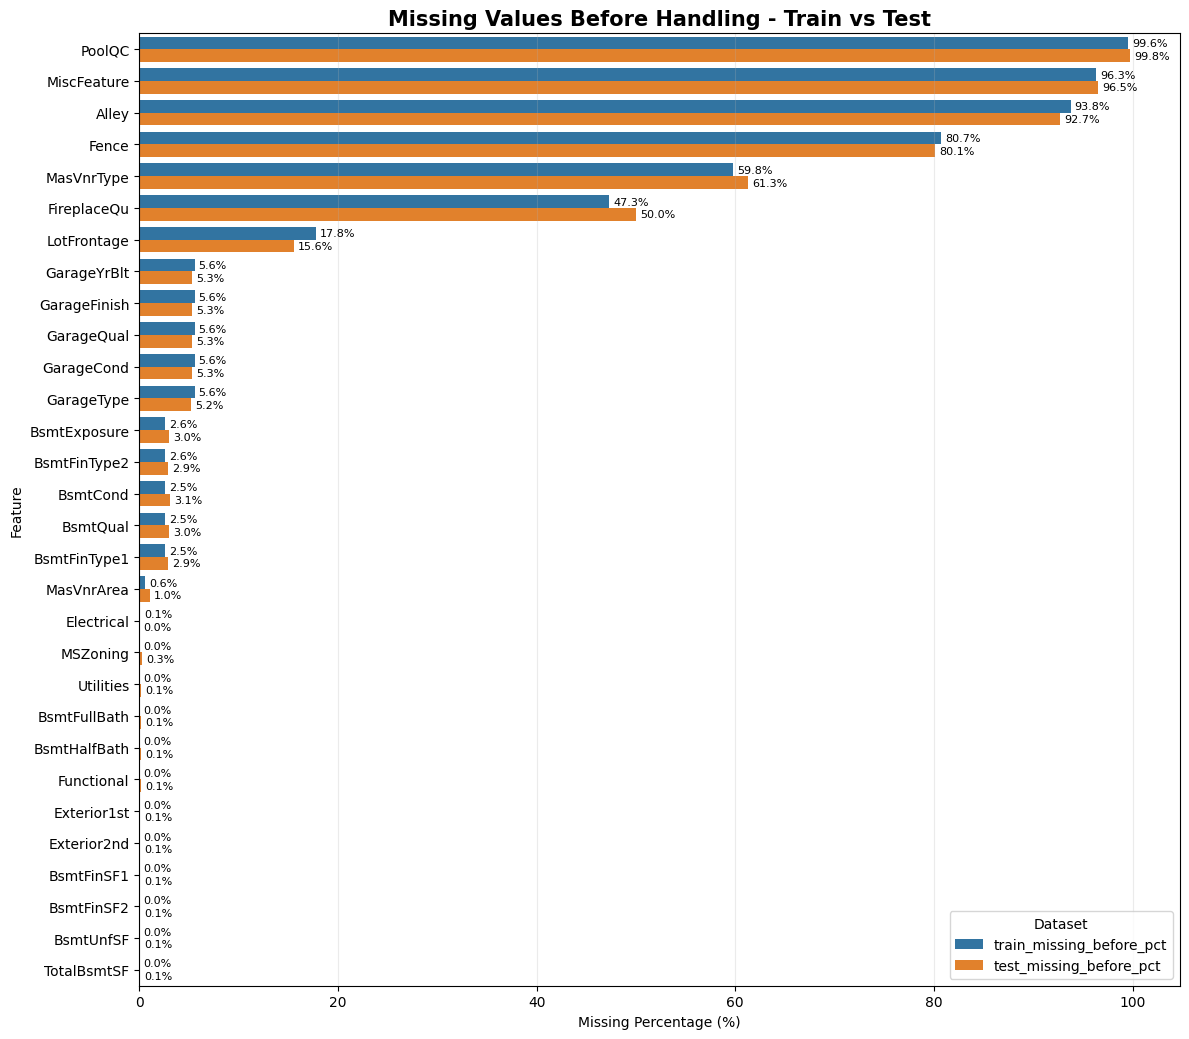

In [65]:
# ============================================================
# 4.4 Plot missing values before handling
# ============================================================

plot_df = missing_before_report.loc[
    (missing_before_report["train_missing_before"] > 0) |
    (missing_before_report["test_missing_before"] > 0)
].copy()

plot_df = plot_df.head(30)

if plot_df.empty:
    print("No missing values found before handling.")
else:
    plot_melted = plot_df.melt(
        id_vars="feature",
        value_vars=["train_missing_before_pct", "test_missing_before_pct"],
        var_name="dataset",
        value_name="missing_percentage"
    )

    plt.figure(figsize=(12, max(6, len(plot_df) * 0.35)))

    ax = sns.barplot(
        data=plot_melted,
        x="missing_percentage",
        y="feature",
        hue="dataset"
    )

    plt.title("Missing Values Before Handling - Train vs Test", fontsize=15, fontweight="bold")
    plt.xlabel("Missing Percentage (%)")
    plt.ylabel("Feature")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=8)

    plt.grid(axis="x", alpha=0.25)
    plt.legend(title="Dataset")
    plt.tight_layout()
    plt.savefig(
        FE_PLOT_DIR / "04_01_missing_before_handling_train_test.png",
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()

### Missingness matrix before handling

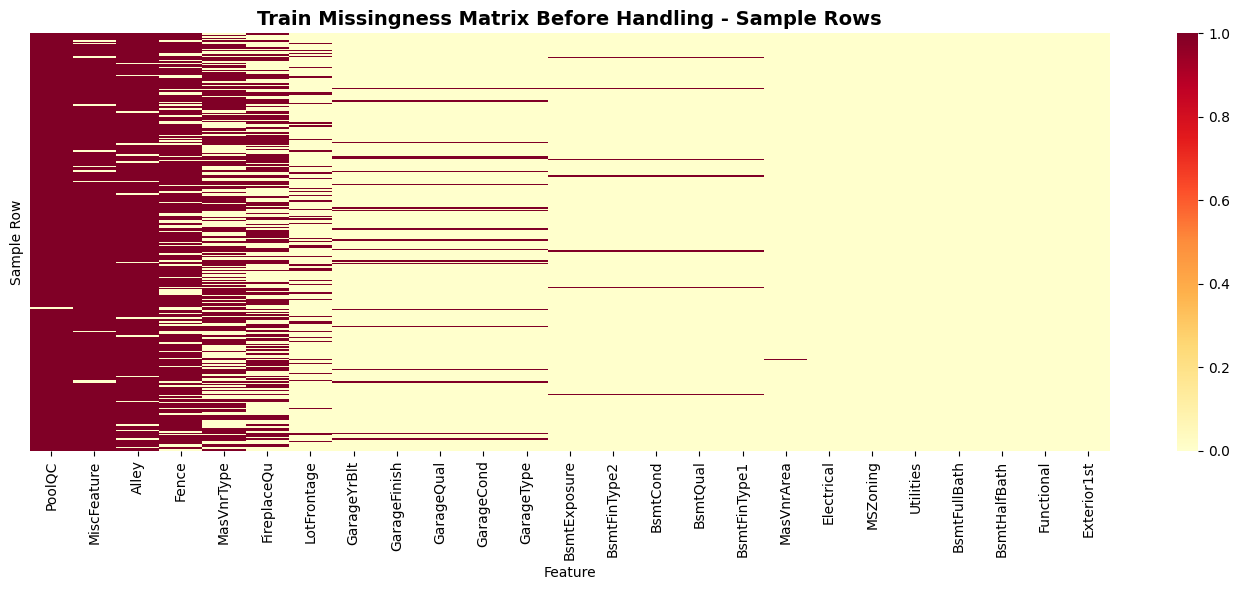

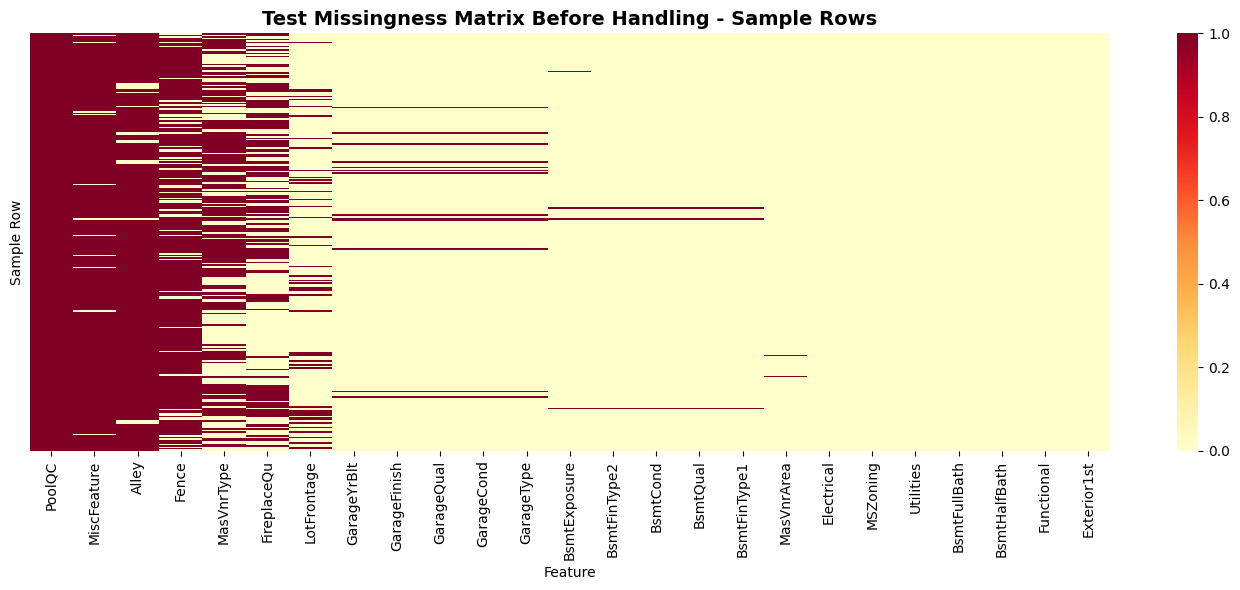

In [66]:
# ============================================================
# 4.5 Missingness matrix before handling
# ============================================================

missing_cols_before = missing_before_report.loc[
    (missing_before_report["train_missing_before"] > 0) |
    (missing_before_report["test_missing_before"] > 0),
    "feature"
].tolist()

missing_cols_before = missing_cols_before[:25]

if len(missing_cols_before) == 0:
    print("No missing columns available for missingness matrix.")
else:
    sample_train = X_train_missing[missing_cols_before].head(300).isna().astype(int)
    sample_test = X_test_missing[missing_cols_before].head(300).isna().astype(int)

    plt.figure(figsize=(14, 6))
    sns.heatmap(
        sample_train,
        cbar=True,
        cmap="YlOrRd",
        yticklabels=False
    )
    plt.title("Train Missingness Matrix Before Handling - Sample Rows", fontsize=14, fontweight="bold")
    plt.xlabel("Feature")
    plt.ylabel("Sample Row")
    plt.tight_layout()
    plt.savefig(
        FE_PLOT_DIR / "04_02_train_missingness_matrix_before.png",
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()

    plt.figure(figsize=(14, 6))
    sns.heatmap(
        sample_test,
        cbar=True,
        cmap="YlOrRd",
        yticklabels=False
    )
    plt.title("Test Missingness Matrix Before Handling - Sample Rows", fontsize=14, fontweight="bold")
    plt.xlabel("Feature")
    plt.ylabel("Sample Row")
    plt.tight_layout()
    plt.savefig(
        FE_PLOT_DIR / "04_03_test_missingness_matrix_before.png",
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()

### Fit missing handling artifacts from train only

In [67]:
# ============================================================
# 4.6 Fit missing handling artifacts from train only
# ============================================================

missing_artifacts = {
    "mode_values": {},
    "numeric_medians": {},
    "lotfrontage_neighborhood_median": None,
    "lotfrontage_global_median": None,
    "allowed_remaining_missing": ["GarageYrBlt"]
}

# Mode values from train only
for col in MODE_FILL_COLUMNS:
    if col in X_train_missing.columns:
        mode_values = X_train_missing[col].dropna().mode()
        missing_artifacts["mode_values"][col] = mode_values.iloc[0] if len(mode_values) > 0 else "Unknown"

# Numeric medians from train only
for col in X_train_missing.select_dtypes(include=[np.number]).columns:
    if col != ID_COL:
        missing_artifacts["numeric_medians"][col] = X_train_missing[col].median()

# LotFrontage Neighborhood median from train only
if {"LotFrontage", "Neighborhood"}.issubset(X_train_missing.columns):
    lotfrontage_neighborhood_median = (
        X_train_missing
        .groupby("Neighborhood")["LotFrontage"]
        .median()
    )

    missing_artifacts["lotfrontage_neighborhood_median"] = lotfrontage_neighborhood_median.to_dict()
    missing_artifacts["lotfrontage_global_median"] = X_train_missing["LotFrontage"].median()

print("Missing handling artifacts fitted from train only.")

Missing handling artifacts fitted from train only.


### Fill absence-related categorical columns with "None"

In [68]:
# ============================================================
# 4.7 Fill absence-related categorical columns with None
# ============================================================

none_fill_existing = keep_existing_columns(
    NONE_FILL_COLUMNS,
    X_train_missing,
    X_test_missing
)

for col in none_fill_existing:
    X_train_missing[col] = X_train_missing[col].fillna("None")
    X_test_missing[col] = X_test_missing[col].fillna("None")

print("None-filled categorical absence columns:", len(none_fill_existing))
none_fill_existing

None-filled categorical absence columns: 15


['Alley',
 'MasVnrType',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PoolQC',
 'Fence',
 'MiscFeature']

### Fill absence-related numeric columns with 0

In [69]:
# ============================================================
# 4.8 Fill absence-related numeric columns with 0
# ============================================================

zero_fill_existing = keep_existing_columns(
    ZERO_FILL_COLUMNS,
    X_train_missing,
    X_test_missing
)

for col in zero_fill_existing:
    X_train_missing[col] = X_train_missing[col].fillna(0)
    X_test_missing[col] = X_test_missing[col].fillna(0)

print("Zero-filled numeric absence columns:", len(zero_fill_existing))
zero_fill_existing

Zero-filled numeric absence columns: 11


['MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 'BsmtFullBath',
 'BsmtHalfBath',
 'GarageCars',
 'GarageArea',
 'PoolArea',
 'MiscVal']

### Fill LotFrontage using Neighborhood median

In [70]:
# ============================================================
# 4.9 Fill LotFrontage by Neighborhood median
# ============================================================

if {"LotFrontage", "Neighborhood"}.issubset(X_train_missing.columns):
    neighborhood_median_map = missing_artifacts["lotfrontage_neighborhood_median"]
    global_lotfrontage_median = missing_artifacts["lotfrontage_global_median"]

    train_lotfrontage_fill = X_train_missing["Neighborhood"].map(neighborhood_median_map)
    test_lotfrontage_fill = X_test_missing["Neighborhood"].map(neighborhood_median_map)

    X_train_missing["LotFrontage"] = X_train_missing["LotFrontage"].fillna(train_lotfrontage_fill)
    X_train_missing["LotFrontage"] = X_train_missing["LotFrontage"].fillna(global_lotfrontage_median)

    X_test_missing["LotFrontage"] = X_test_missing["LotFrontage"].fillna(test_lotfrontage_fill)
    X_test_missing["LotFrontage"] = X_test_missing["LotFrontage"].fillna(global_lotfrontage_median)

    print("LotFrontage filled using Neighborhood median, fallback global median.")
else:
    print("LotFrontage or Neighborhood not found. Skipped.")

LotFrontage filled using Neighborhood median, fallback global median.


### Fill low-missing categorical columns with train mode

In [71]:
# ============================================================
# 4.10 Fill low-missing categorical columns with train mode
# ============================================================

mode_fill_existing = keep_existing_columns(
    MODE_FILL_COLUMNS,
    X_train_missing,
    X_test_missing
)

for col in mode_fill_existing:
    fill_value = missing_artifacts["mode_values"].get(col, "Unknown")

    X_train_missing[col] = X_train_missing[col].fillna(fill_value)
    X_test_missing[col] = X_test_missing[col].fillna(fill_value)

print("Mode-filled columns:", len(mode_fill_existing))
mode_fill_existing

Mode-filled columns: 8


['MSZoning',
 'Utilities',
 'Exterior1st',
 'Exterior2nd',
 'Electrical',
 'KitchenQual',
 'Functional',
 'SaleType']

### Safety fill remaining categorical missing values

In [72]:
# ============================================================
# 4.11 Safety fill remaining categorical missing values
# ============================================================

categorical_safety_fill_rows = []

for df_name, df in [("train", X_train_missing), ("test", X_test_missing)]:
    cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

    for col in cat_cols:
        missing_count = df[col].isna().sum()

        if missing_count > 0:
            categorical_safety_fill_rows.append({
                "dataset": df_name,
                "feature": col,
                "missing_filled": int(missing_count),
                "fill_value": "Unknown"
            })

            df[col] = df[col].fillna("Unknown")

categorical_safety_fill_report = pd.DataFrame(categorical_safety_fill_rows)

categorical_safety_fill_report.to_csv(
    FE_STEP_REPORT_DIR / "16_categorical_safety_fill_report.csv",
    index=False
)

categorical_safety_fill_report

""


### Safety fill remaining numeric missing values except GarageYrBlt

In [73]:
# ============================================================
# 4.12 Safety fill remaining numeric missing values except GarageYrBlt
# ============================================================

allowed_remaining_missing = ["GarageYrBlt"]

numeric_safety_fill_rows = []

for df_name, df in [("train", X_train_missing), ("test", X_test_missing)]:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    for col in numeric_cols:
        if col in allowed_remaining_missing:
            continue

        if col == ID_COL:
            continue

        missing_count = df[col].isna().sum()

        if missing_count > 0:
            fill_value = missing_artifacts["numeric_medians"].get(col, X_train_missing[col].median())

            numeric_safety_fill_rows.append({
                "dataset": df_name,
                "feature": col,
                "missing_filled": int(missing_count),
                "fill_value": fill_value
            })

            df[col] = df[col].fillna(fill_value)

numeric_safety_fill_report = pd.DataFrame(numeric_safety_fill_rows)

numeric_safety_fill_report.to_csv(
    FE_STEP_REPORT_DIR / "17_numeric_safety_fill_report.csv",
    index=False
)

numeric_safety_fill_report

""


### Missing count after handling

In [74]:
# ============================================================
# 4.13 Missing count after handling
# ============================================================

missing_after_rows = []

for col in X_train_missing.columns:
    missing_after_rows.append({
        "feature": col,
        "train_missing_after": X_train_missing[col].isna().sum(),
        "train_missing_after_pct": round(X_train_missing[col].isna().mean() * 100, 2),
        "test_missing_after": X_test_missing[col].isna().sum() if col in X_test_missing.columns else np.nan,
        "test_missing_after_pct": round(X_test_missing[col].isna().mean() * 100, 2) if col in X_test_missing.columns else np.nan,
    })

missing_after_report = pd.DataFrame(missing_after_rows)

missing_handling_report = missing_before_report.merge(
    missing_after_report,
    on="feature",
    how="left"
)

missing_handling_report["train_missing_reduced"] = (
    missing_handling_report["train_missing_before"] -
    missing_handling_report["train_missing_after"]
)

missing_handling_report["test_missing_reduced"] = (
    missing_handling_report["test_missing_before"] -
    missing_handling_report["test_missing_after"]
)

def assign_missing_strategy(feature):
    if feature in NONE_FILL_COLUMNS:
        return "fill with None"
    if feature in ZERO_FILL_COLUMNS:
        return "fill with 0"
    if feature == "LotFrontage":
        return "Neighborhood median, fallback global median"
    if feature in MODE_FILL_COLUMNS:
        return "train mode"
    if feature == "GarageYrBlt":
        return "intentionally kept for GarageAge feature creation"
    return "safety fallback if needed"

missing_handling_report["missing_strategy"] = missing_handling_report["feature"].apply(
    assign_missing_strategy
)

missing_handling_report.to_csv(
    FE_STEP_REPORT_DIR / "18_missing_handling_report.csv",
    index=False
)

missing_handling_report.sort_values(
    ["train_missing_before", "test_missing_before"],
    ascending=False
).head(50)

,feature,train_missing_before,train_missing_before_pct,test_missing_before,test_missing_before_pct,train_missing_after,train_missing_after_pct,test_missing_after,test_missing_after_pct,train_missing_reduced,test_missing_reduced,missing_strategy
0,PoolQC,1452,99.59,1456,99.79,0,0.00,0,0.00,1452,1456,fill with None
1,MiscFeature,1404,96.30,1408,96.50,0,0.00,0,0.00,1404,1408,fill with None
2,Alley,1367,93.76,1352,92.67,0,0.00,0,0.00,1367,1352,fill with None
3,Fence,1177,80.73,1169,80.12,0,0.00,0,0.00,1177,1169,fill with None
4,MasVnrType,872,59.81,894,61.27,0,0.00,0,0.00,872,894,fill with None
5,FireplaceQu,690,47.33,730,50.03,0,0.00,0,0.00,690,730,fill with None
6,LotFrontage,259,17.76,227,15.56,0,0.00,0,0.00,259,227,"Neighborhood median, fallback global median"
7,GarageYrBlt,81,5.56,78,5.35,81,5.56,78,5.35,0,0,intentionally kept for GarageAge feature creation
8,GarageFinish,81,5.56,78,5.35,0,0.00,0,0.00,81,78,fill with None
9,GarageQual,81,5.56,78,5.35,0,0.00,0,0.00,81,78,fill with None


Plot missing before vs after

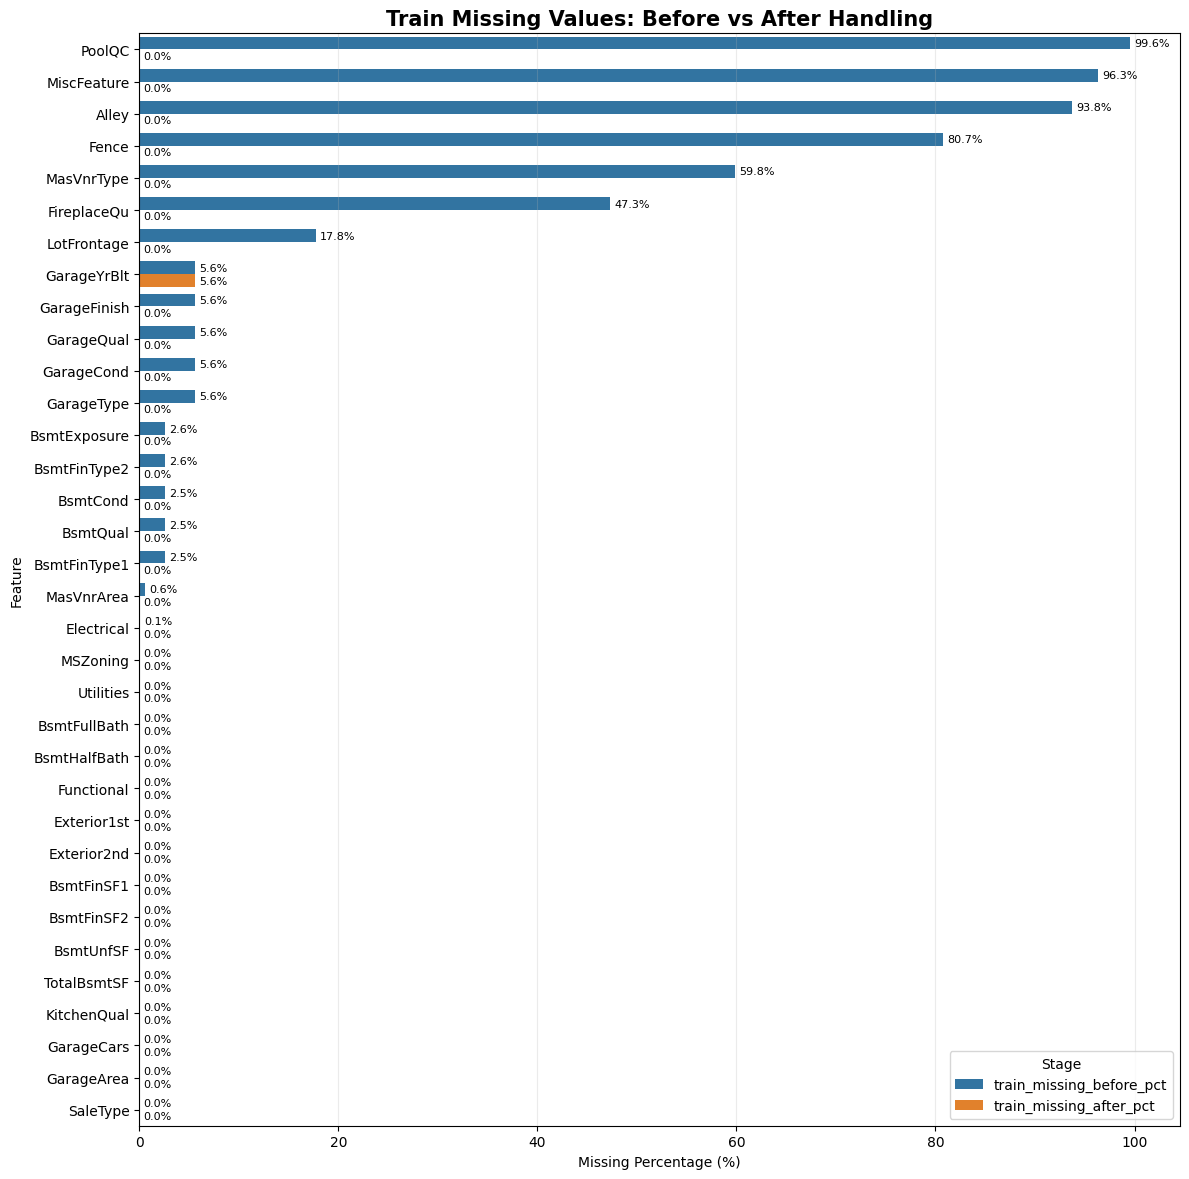

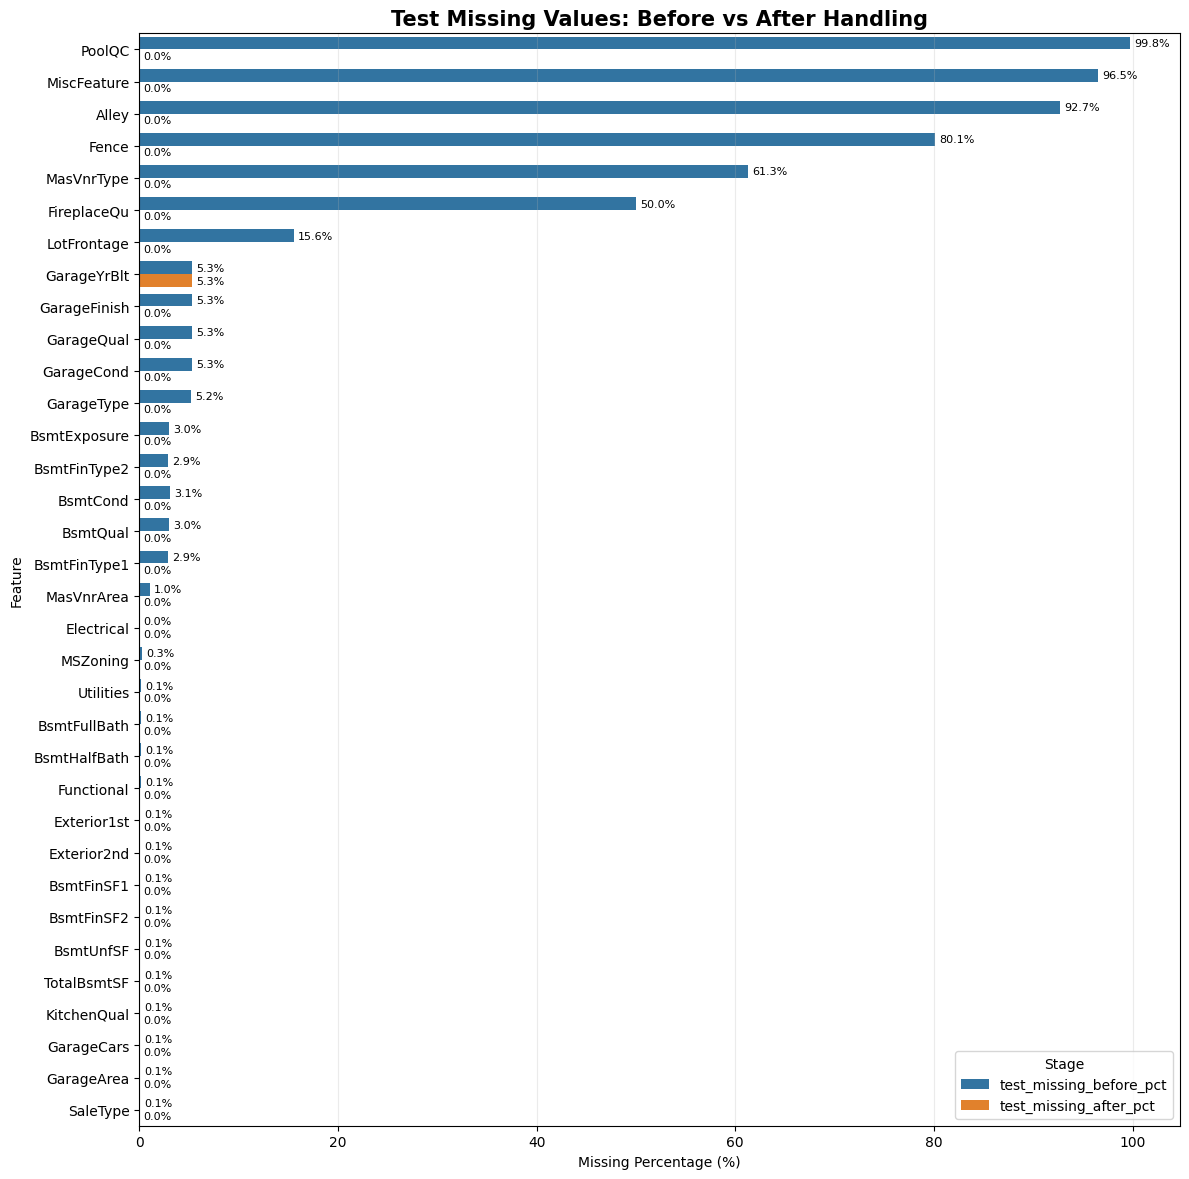

In [75]:
# ============================================================
# 4.14 Plot missing before vs after
# ============================================================

plot_df = missing_handling_report.loc[
    (missing_handling_report["train_missing_before"] > 0) |
    (missing_handling_report["test_missing_before"] > 0) |
    (missing_handling_report["train_missing_after"] > 0) |
    (missing_handling_report["test_missing_after"] > 0)
].copy()

plot_df = plot_df.head(35)

if plot_df.empty:
    print("No missing values to plot.")
else:
    train_plot = plot_df[[
        "feature",
        "train_missing_before_pct",
        "train_missing_after_pct"
    ]].melt(
        id_vars="feature",
        var_name="stage",
        value_name="missing_percentage"
    )

    plt.figure(figsize=(12, max(6, len(plot_df) * 0.35)))

    ax = sns.barplot(
        data=train_plot,
        x="missing_percentage",
        y="feature",
        hue="stage"
    )

    plt.title("Train Missing Values: Before vs After Handling", fontsize=15, fontweight="bold")
    plt.xlabel("Missing Percentage (%)")
    plt.ylabel("Feature")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=8)

    plt.grid(axis="x", alpha=0.25)
    plt.legend(title="Stage")
    plt.tight_layout()
    plt.savefig(
        FE_PLOT_DIR / "04_04_train_missing_before_after.png",
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()


    test_plot = plot_df[[
        "feature",
        "test_missing_before_pct",
        "test_missing_after_pct"
    ]].melt(
        id_vars="feature",
        var_name="stage",
        value_name="missing_percentage"
    )

    plt.figure(figsize=(12, max(6, len(plot_df) * 0.35)))

    ax = sns.barplot(
        data=test_plot,
        x="missing_percentage",
        y="feature",
        hue="stage"
    )

    plt.title("Test Missing Values: Before vs After Handling", fontsize=15, fontweight="bold")
    plt.xlabel("Missing Percentage (%)")
    plt.ylabel("Feature")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=8)

    plt.grid(axis="x", alpha=0.25)
    plt.legend(title="Stage")
    plt.tight_layout()
    plt.savefig(
        FE_PLOT_DIR / "04_05_test_missing_before_after.png",
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()

### Plot missing reduction by feature

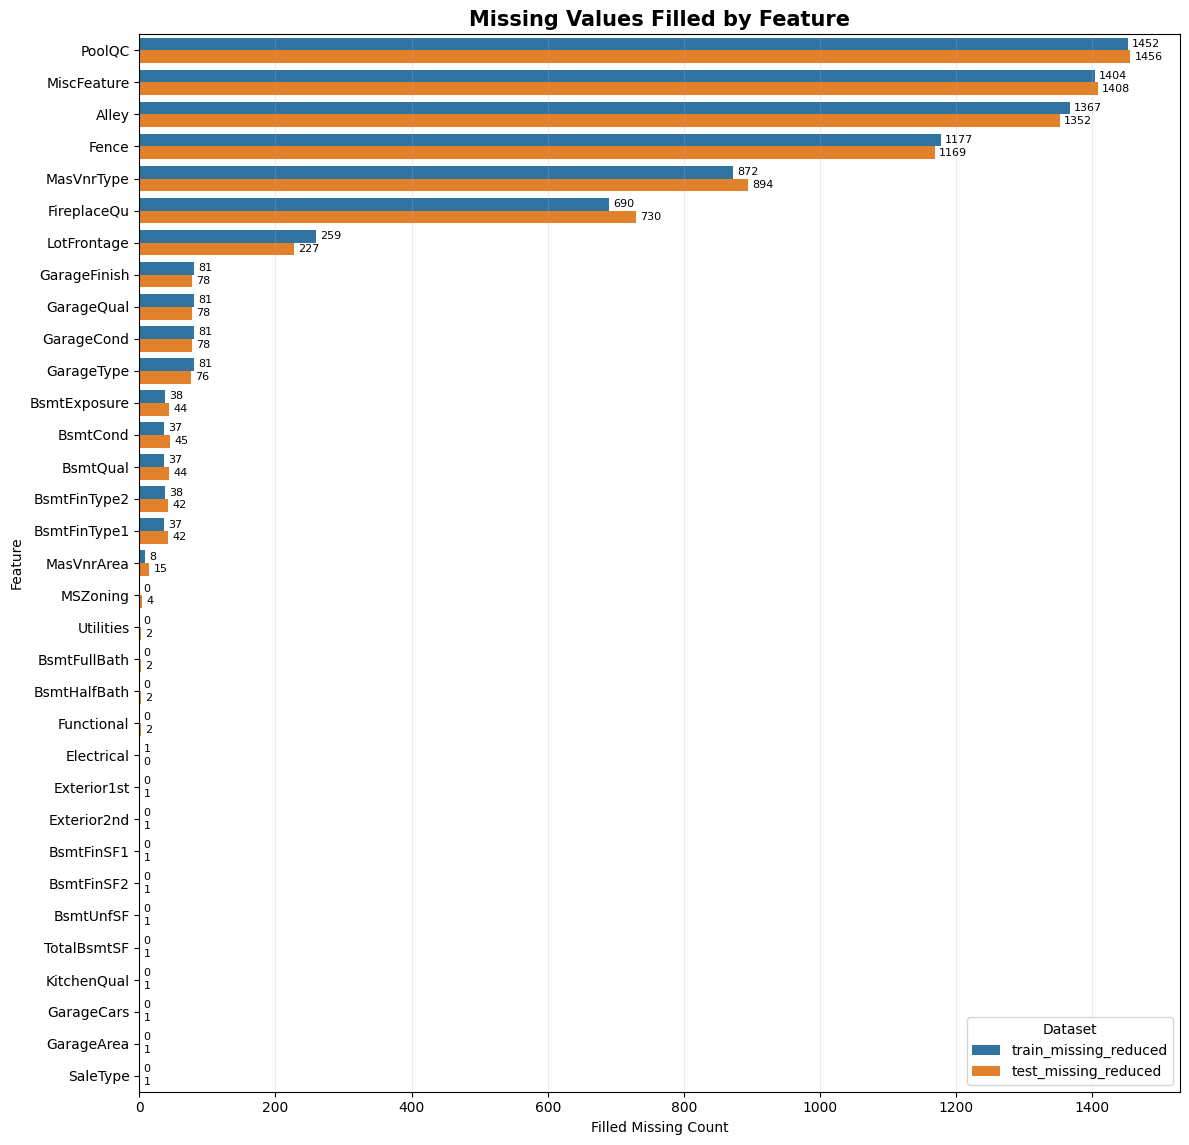

In [76]:
# ============================================================
# 4.15 Plot missing reduction by feature
# ============================================================

reduction_df = missing_handling_report.loc[
    (missing_handling_report["train_missing_reduced"] > 0) |
    (missing_handling_report["test_missing_reduced"] > 0)
].copy()

reduction_df["total_missing_reduced"] = (
    reduction_df["train_missing_reduced"] +
    reduction_df["test_missing_reduced"]
)

reduction_df = reduction_df.sort_values(
    "total_missing_reduced",
    ascending=False
).head(35)

if reduction_df.empty:
    print("No missing value reduction found.")
else:
    reduction_plot = reduction_df[[
        "feature",
        "train_missing_reduced",
        "test_missing_reduced"
    ]].melt(
        id_vars="feature",
        var_name="dataset",
        value_name="missing_reduced_count"
    )

    plt.figure(figsize=(12, max(6, len(reduction_df) * 0.35)))

    ax = sns.barplot(
        data=reduction_plot,
        x="missing_reduced_count",
        y="feature",
        hue="dataset"
    )

    plt.title("Missing Values Filled by Feature", fontsize=15, fontweight="bold")
    plt.xlabel("Filled Missing Count")
    plt.ylabel("Feature")

    for container in ax.containers:
        ax.bar_label(container, padding=3, fontsize=8)

    plt.grid(axis="x", alpha=0.25)
    plt.legend(title="Dataset")
    plt.tight_layout()
    plt.savefig(
        FE_PLOT_DIR / "04_06_missing_reduction_by_feature.png",
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()

### Plot missing strategy summary

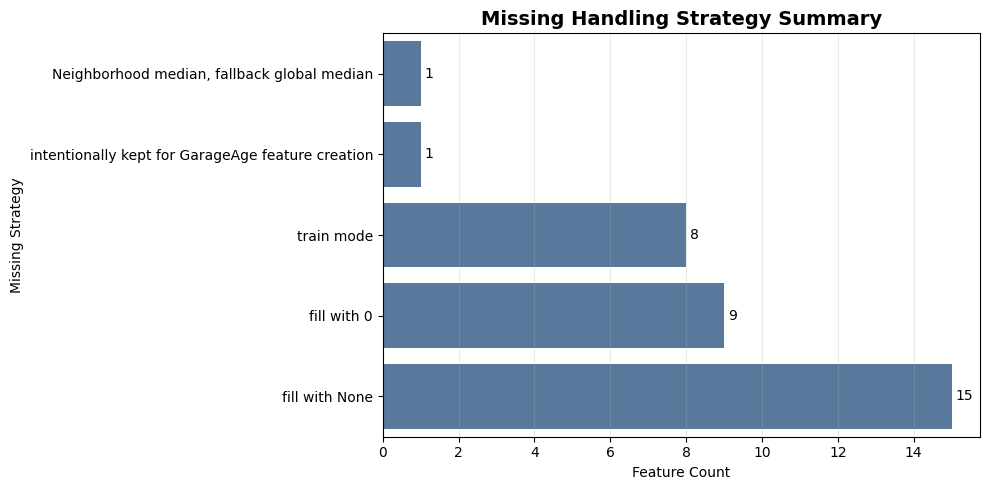

,missing_strategy,feature_count,train_missing_filled,test_missing_filled
0,"Neighborhood median, fallback global median",1,259,227
1,fill with 0,9,8,25
2,fill with None,15,7473,7536
3,intentionally kept for GarageAge feature creation,1,0,0
4,train mode,8,1,12


In [77]:
# ============================================================
# 4.16 Plot missing strategy summary
# ============================================================

strategy_summary = (
    missing_handling_report
    .loc[
        (missing_handling_report["train_missing_before"] > 0) |
        (missing_handling_report["test_missing_before"] > 0)
    ]
    .groupby("missing_strategy")
    .agg(
        feature_count=("feature", "count"),
        train_missing_filled=("train_missing_reduced", "sum"),
        test_missing_filled=("test_missing_reduced", "sum")
    )
    .reset_index()
)

strategy_summary.to_csv(
    FE_STEP_REPORT_DIR / "19_missing_strategy_summary.csv",
    index=False
)

if strategy_summary.empty:
    print("No missing strategy summary to plot.")
else:
    plt.figure(figsize=(10, 5))

    ax = sns.barplot(
        data=strategy_summary.sort_values("feature_count", ascending=True),
        x="feature_count",
        y="missing_strategy",
        color="#4E79A7"
    )

    plt.title("Missing Handling Strategy Summary", fontsize=14, fontweight="bold")
    plt.xlabel("Feature Count")
    plt.ylabel("Missing Strategy")

    for container in ax.containers:
        ax.bar_label(container, padding=3)

    plt.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.savefig(
        FE_PLOT_DIR / "04_07_missing_strategy_summary.png",
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()

strategy_summary

### Missingness matrix after handling

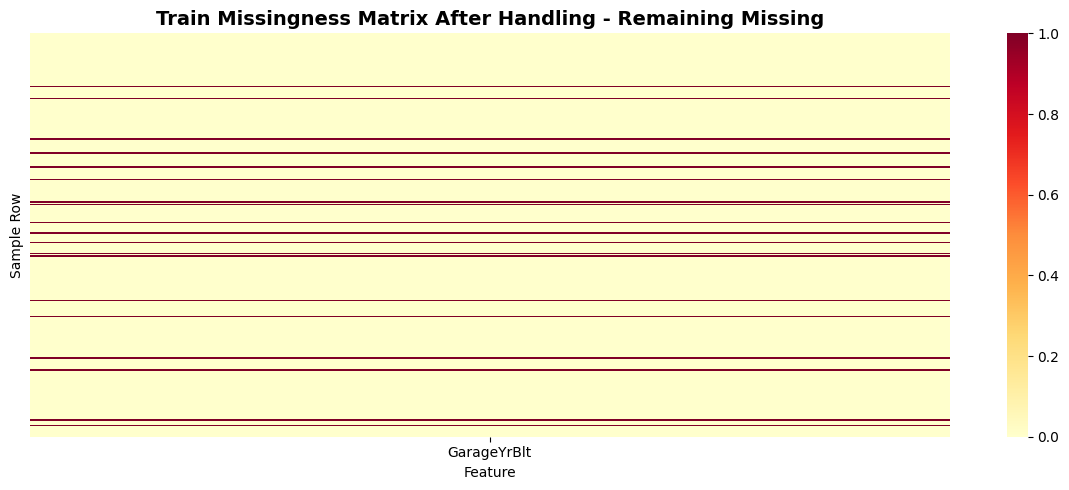

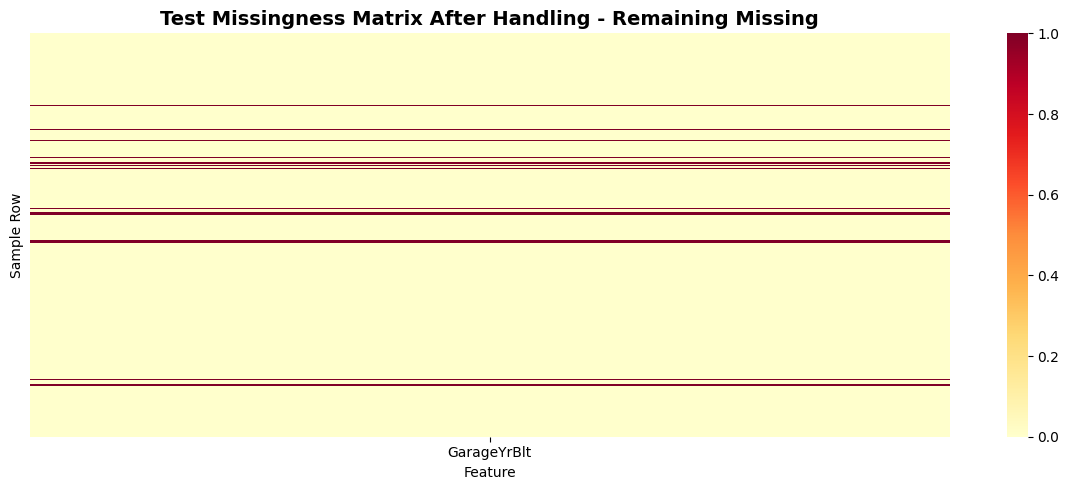

In [78]:
# ============================================================
# 4.17 Missingness matrix after handling
# ============================================================

remaining_missing_cols = missing_handling_report.loc[
    (missing_handling_report["train_missing_after"] > 0) |
    (missing_handling_report["test_missing_after"] > 0),
    "feature"
].tolist()

if len(remaining_missing_cols) == 0:
    print("No remaining missing values after handling.")
else:
    remaining_missing_cols = remaining_missing_cols[:25]

    sample_train_after = X_train_missing[remaining_missing_cols].head(300).isna().astype(int)
    sample_test_after = X_test_missing[remaining_missing_cols].head(300).isna().astype(int)

    plt.figure(figsize=(12, 5))
    sns.heatmap(
        sample_train_after,
        cbar=True,
        cmap="YlOrRd",
        yticklabels=False
    )
    plt.title("Train Missingness Matrix After Handling - Remaining Missing", fontsize=14, fontweight="bold")
    plt.xlabel("Feature")
    plt.ylabel("Sample Row")
    plt.tight_layout()
    plt.savefig(
        FE_PLOT_DIR / "04_08_train_missingness_matrix_after.png",
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()

    plt.figure(figsize=(12, 5))
    sns.heatmap(
        sample_test_after,
        cbar=True,
        cmap="YlOrRd",
        yticklabels=False
    )
    plt.title("Test Missingness Matrix After Handling - Remaining Missing", fontsize=14, fontweight="bold")
    plt.xlabel("Feature")
    plt.ylabel("Sample Row")
    plt.tight_layout()
    plt.savefig(
        FE_PLOT_DIR / "04_09_test_missingness_matrix_after.png",
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()

### Remaining missing report

In [79]:
# ============================================================
# 4.18 Remaining missing report
# ============================================================

remaining_missing_report = missing_handling_report.loc[
    (missing_handling_report["train_missing_after"] > 0) |
    (missing_handling_report["test_missing_after"] > 0)
].copy()

remaining_missing_report.to_csv(
    FE_STEP_REPORT_DIR / "20_remaining_missing_after_handling_report.csv",
    index=False
)

remaining_missing_report

,feature,train_missing_before,train_missing_before_pct,test_missing_before,test_missing_before_pct,train_missing_after,train_missing_after_pct,test_missing_after,test_missing_after_pct,train_missing_reduced,test_missing_reduced,missing_strategy
7,GarageYrBlt,81,5.56,78,5.35,81,5.56,78,5.35,0,0,intentionally kept for GarageAge feature creation


In [80]:
# ============================================================
# 4.19 Save missing handling artifacts
# ============================================================

joblib.dump(
    missing_artifacts,
    FE_RESULT_DIR / "04_missing_handling_artifacts.joblib"
)

print("Saved missing handling artifacts:")
print(FE_RESULT_DIR / "04_missing_handling_artifacts.joblib")

Saved missing handling artifacts:
C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression\fe_result\04_missing_handling_artifacts.joblib


In [81]:
# ============================================================
# 4.20 Save missing-handled datasets
# ============================================================

X_train_missing.to_csv(
    FE_RESULT_DIR / "04_X_train_missing_handled.csv",
    index=False
)

X_test_missing.to_csv(
    FE_RESULT_DIR / "04_X_test_missing_handled.csv",
    index=False
)

print("Saved:")
print(FE_RESULT_DIR / "04_X_train_missing_handled.csv")
print(FE_RESULT_DIR / "04_X_test_missing_handled.csv")

Saved:
C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression\fe_result\04_X_train_missing_handled.csv
C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression\fe_result\04_X_test_missing_handled.csv


In [82]:
# ============================================================
# 4.21 Final safety check
# ============================================================

train_remaining_missing_cols = X_train_missing.columns[
    X_train_missing.isna().sum() > 0
].tolist()

test_remaining_missing_cols = X_test_missing.columns[
    X_test_missing.isna().sum() > 0
].tolist()

allowed_remaining_missing = ["GarageYrBlt"]

unexpected_train_missing = [
    col for col in train_remaining_missing_cols
    if col not in allowed_remaining_missing
]

unexpected_test_missing = [
    col for col in test_remaining_missing_cols
    if col not in allowed_remaining_missing
]

print("Train remaining missing columns:", train_remaining_missing_cols)
print("Test remaining missing columns:", test_remaining_missing_cols)

if len(unexpected_train_missing) > 0 or len(unexpected_test_missing) > 0:
    raise ValueError(
        f"Unexpected missing values remain. Train: {unexpected_train_missing}, Test: {unexpected_test_missing}"
    )

assert X_train_missing.shape[0] == y_train_log_fe.shape[0]
assert X_test_missing.shape[0] == test_ids_fe.shape[0]

print("Missing value handling completed successfully.")
print("Allowed remaining missing:", allowed_remaining_missing)

Train remaining missing columns: ['GarageYrBlt']
Test remaining missing columns: ['GarageYrBlt']
Missing value handling completed successfully.
Allowed remaining missing: ['GarageYrBlt']


### Manual Decision from Missing Value Handling

Missing value handling has been completed using the previous EDA decisions.

This section did not create new EDA decisions.  
The plots were used only to validate whether the missing handling pipeline worked correctly.

---

### Key Findings Before Missing Handling

Before handling, missing values were concentrated in a few known feature groups:

#### High-missing absence features

The highest missing features were:

- `PoolQC`
- `MiscFeature`
- `Alley`
- `Fence`
- `MasVnrType`
- `FireplaceQu`

These features have very high missing percentages because most houses do not have those components.

Manual decision:

- Treat missing values in these columns as **absence**, not unknown.
- Fill them with `"None"`.

---

#### Garage-related missing values

Garage-related columns had around 5% missing values:

- `GarageType`
- `GarageFinish`
- `GarageQual`
- `GarageCond`
- `GarageYrBlt`

Manual decision:

- Missing garage categorical values mean **no garage**.
- Fill garage categorical columns with `"None"`.
- Keep `GarageYrBlt` temporarily missing because it will be handled during feature creation.

Reason:

`GarageYrBlt` should not be filled with median directly.  
Missing `GarageYrBlt` usually means the house has no garage. Median filling would create fake garage-year information.

---

#### Basement-related missing values

Basement-related columns had low but meaningful missingness:

- `BsmtQual`
- `BsmtCond`
- `BsmtExposure`
- `BsmtFinType1`
- `BsmtFinType2`

Manual decision:

- Missing basement categorical values mean **no basement**.
- Fill them with `"None"`.

---

#### LotFrontage missing values

`LotFrontage` had moderate missingness:

- Train: around 17.8%
- Test: around 15.6%

Manual decision:

- Fill `LotFrontage` using train-based `Neighborhood` median.
- Use global train median as fallback.

Reason:

`LotFrontage` is location-sensitive.  
Neighborhood median is more meaningful than global median alone.

---

### Missing Handling Strategy Applied

The missing handling strategy summary confirms:

| Strategy | Feature Count | Decision |
|---|---:|---|
| fill with `None` | 15 | absence-related categorical features |
| fill with `0` | 9 | absence-related numeric features |
| train mode | 8 | low-missing categorical features |
| Neighborhood median, fallback global median | 1 | `LotFrontage` |
| intentionally kept for GarageAge feature creation | 1 | `GarageYrBlt` |

This strategy is correct and aligned with the EDA decisions.

---

### After Missing Handling

After applying the missing value decisions:

- Most missing values were fully handled.
- Train and test missingness became consistent.
- The only remaining missing feature is:

```text
GarageYrBlt